In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from datetime import timedelta

import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("CUSTOMER-LEVEL SUBSIDY ANALYSIS")
print("="*80)

df_clean = pd.read_csv('cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

print("\n" + "="*80)
print("ADDING SUBSIDY INFORMATION TO QUOTE-LEVEL DATA")
print("="*80)

df_clean['subsidy_issue'] = (df_clean['mt_prime_cee'] < 0) | (df_clean['mt_prime_maprimerenov'] < 0)
df_clean['subsidy_issue_cee'] = df_clean['mt_prime_cee'] < 0
df_clean['subsidy_issue_maprimerenov'] = df_clean['mt_prime_maprimerenov'] < 0

df_clean['positive_cee'] = df_clean['mt_prime_cee'].clip(lower=0)
df_clean['positive_maprimerenov'] = df_clean['mt_prime_maprimerenov'].clip(lower=0)
df_clean['negative_cee'] = df_clean['mt_prime_cee'].clip(upper=0).abs()
df_clean['negative_maprimerenov'] = df_clean['mt_prime_maprimerenov'].clip(upper=0).abs()

df_clean['total_positive_subsidy'] = df_clean['positive_cee'] + df_clean['positive_maprimerenov']
df_clean['total_negative_subsidy'] = df_clean['negative_cee'] + df_clean['negative_maprimerenov']
df_clean['net_subsidy'] = df_clean['mt_prime_cee'] + df_clean['mt_prime_maprimerenov']

print(f"Quotes with subsidy issues: {df_clean['subsidy_issue'].sum():,} ({df_clean['subsidy_issue'].mean():.1%})")

CUSTOMER-LEVEL SUBSIDY ANALYSIS
Loaded data: 34,014 quotes from 23,888 customers

ADDING SUBSIDY INFORMATION TO QUOTE-LEVEL DATA
Quotes with subsidy issues: 8,380 (24.6%)


In [2]:
def aggregate_by_customer(df):
    """
    Single, comprehensive customer-level aggregation for all analyses
    """
    # First, create all necessary quote-level columns
    df = df.copy()
    
    # Subsidy flags
    df['subsidy_issue'] = (df['mt_prime_cee'] < 0) | (df['mt_prime_maprimerenov'] < 0)
    df['subsidy_issue_cee'] = df['mt_prime_cee'] < 0
    df['subsidy_issue_maprimerenov'] = df['mt_prime_maprimerenov'] < 0
    
    # Positive subsidies (actual money received)
    df['positive_cee'] = df['mt_prime_cee'].clip(lower=0)
    df['positive_maprimerenov'] = df['mt_prime_maprimerenov'].clip(lower=0)
    df['total_positive_subsidy'] = df['positive_cee'] + df['positive_maprimerenov']
    
    # Negative subsidies (adjustments/clawbacks)
    df['negative_cee'] = df['mt_prime_cee'].clip(upper=0).abs()
    df['negative_maprimerenov'] = df['mt_prime_maprimerenov'].clip(upper=0).abs()
    df['total_negative_subsidy'] = df['negative_cee'] + df['negative_maprimerenov']
    
    # Net subsidy
    df['net_subsidy'] = df['mt_prime_cee'] + df['mt_prime_maprimerenov']
    
    # Out-of-pocket price (after positive subsidies)
    df['positive_subsidy'] = df[['mt_prime_cee', 'mt_prime_maprimerenov']].clip(lower=0).sum(axis=1)
    df['out_of_pocket'] = df['mt_ttc_avant_aide_devis'] - df['positive_subsidy']
    
    # Heat pump flag
    df['is_heat_pump'] = df['famille_equipement_produit'].str.contains('PAC|POMPE|HEAT|POMPE À CHALEUR', case=False, na=False) | \
                          df['type_equipement_produit'].str.contains('PAC|POMPE|HEAT|POMPE À CHALEUR', case=False, na=False)
    
    # Equipment category
    def categorize_equipment(row):
        if pd.isna(row['famille_equipement_produit']):
            return 'Unknown'
        if row['is_heat_pump']:
            return 'Heat Pump'
        if 'Chaudière' in str(row['famille_equipement_produit']):
            return 'Boiler'
        if 'Climatisation' in str(row['famille_equipement_produit']):
            return 'AC'
        if 'Poêle' in str(row['famille_equipement_produit']):
            return 'Stove'
        return 'Other'
    
    df['equipment_category'] = df.apply(categorize_equipment, axis=1)
    
    # Group by customer
    customer_data = df.groupby('numero_compte').agg({
        # Conversion
        'fg_devis_accepte': 'max',
        
        # Price metrics (using mt_apres_remise_ht_devis for consistency with first version)
        'mt_apres_remise_ht_devis': ['mean', 'min', 'max', 'std', 'count'],
        
        # Out-of-pocket price (for more accurate customer cost)
        'out_of_pocket': ['mean', 'min', 'max', 'std'],
        
        # Price before subsidy
        'mt_ttc_avant_aide_devis': ['mean', 'min', 'max'],
        
        # Dates
        'dt_creation_devis': ['min', 'max'],
        
        # Subsidy info
        'subsidy_issue': 'max',
        'subsidy_issue_cee': 'max',
        'subsidy_issue_maprimerenov': 'max',
        'total_positive_subsidy': 'sum',
        'total_negative_subsidy': 'sum',
        'net_subsidy': 'sum',
        'mt_prime_cee': 'sum',
        'mt_prime_maprimerenov': 'sum',
        'positive_subsidy': 'sum',
        
        # Product info - take mode (most common)
        'equipment_category': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
        'is_heat_pump': 'max',
        'famille_equipement_produit': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
        
        # Geography
        'nom_region': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
        'nom_agence': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
        
        # Customer type
        'statut_client': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
    })
    
    # Flatten column names
    customer_data.columns = [
        # From mt_apres_remise_ht_devis
        'converted',
        'avg_quote_amount', 'min_quote_amount', 'max_quote_amount', 
        'std_quote_amount', 'total_quotes',
        
        # From out_of_pocket
        'avg_out_of_pocket', 'min_out_of_pocket', 'max_out_of_pocket', 'std_out_of_pocket',
        
        # From mt_ttc_avant_aide_devis
        'avg_price_before_subsidy', 'min_price_before_subsidy', 'max_price_before_subsidy',
        
        # Dates
        'first_quote_date', 'last_quote_date',
        
        # Subsidy flags
        'had_subsidy_issue', 'had_negative_cee', 'had_negative_maprimerenov',
        'total_positive_subsidy', 'total_negative_subsidy', 'net_subsidy',
        'total_cee', 'total_maprimerenov', 'total_positive_subsidy_alt',
        
        # Product info
        'main_equipment_category', 'ever_bought_heat_pump', 'main_product_family',
        
        # Geography
        'main_region', 'main_agency',
        
        # Customer type
        'customer_type'
    ]
    
    # Reset index to make numero_compte a column
    customer_data = customer_data.reset_index()
    
    # Calculate derived features
    customer_data['customer_duration_days'] = (
        pd.to_datetime(customer_data['last_quote_date']) - 
        pd.to_datetime(customer_data['first_quote_date'])
    ).dt.days + 1
    
    # Price range (using out_of_pocket for more accurate customer cost)
    customer_data['price_range'] = customer_data['max_out_of_pocket'] - customer_data['min_out_of_pocket']
    
    # Price range using quote amounts (for comparison)
    customer_data['price_range_quotes'] = customer_data['max_quote_amount'] - customer_data['min_quote_amount']
    
    # Price volatility
    customer_data['price_volatility'] = customer_data['std_out_of_pocket'] / customer_data['avg_out_of_pocket'].replace(0, np.nan)
    
    # Flag for multi-quote customers
    customer_data['multiple_quotes'] = (customer_data['total_quotes'] > 1).astype(int)
    
    # Quote pattern category
    def categorize_quote_pattern(row):
        if row['total_quotes'] == 1:
            return 'Single quote'
        elif row['total_quotes'] == 2:
            return 'Two quotes'
        else:
            return 'Three+ quotes'
    
    customer_data['quote_pattern'] = customer_data.apply(categorize_quote_pattern, axis=1)
    
    # Decision speed category
    def categorize_duration(days):
        if days == 1:
            return 'Same day decision'
        elif days <= 7:
            return 'Quick (2-7 days)'
        elif days <= 30:
            return 'Medium (8-30 days)'
        else:
            return 'Long (>30 days)'
    
    customer_data['decision_speed'] = customer_data['customer_duration_days'].apply(categorize_duration)
    
    # Subsidy issue type
    def categorize_subsidy_issues(row):
        if row['had_negative_cee'] and row['had_negative_maprimerenov']:
            return 'Both'
        elif row['had_negative_cee']:
            return 'CEE Only'
        elif row['had_negative_maprimerenov']:
            return 'MaPrimeRénov Only'
        else:
            return 'No Issues'
    
    customer_data['subsidy_issue_type'] = customer_data.apply(categorize_subsidy_issues, axis=1)
    
    # Year and period for time-based analysis
    customer_data['first_quote_year'] = pd.to_datetime(customer_data['first_quote_date']).dt.year
    customer_data['first_quote_month'] = pd.to_datetime(customer_data['first_quote_date']).dt.month
    customer_data['first_quote_quarter'] = pd.to_datetime(customer_data['first_quote_date']).dt.quarter
    
    # Season
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Spring'
        elif month in [6, 7, 8]:
            return 'Summer'
        else:
            return 'Fall'
    
    customer_data['season'] = customer_data['first_quote_month'].apply(get_season)
    
    # Period for year-over-year comparison
    customer_data['period'] = customer_data['first_quote_year'].astype(str)
    
    # Suspension flag (based on French subsidy suspension dates)
    suspension_start = pd.to_datetime('2025-07-01')
    suspension_end = pd.to_datetime('2025-09-30')
    suspension_start2 = pd.to_datetime('2026-01-01')
    suspension_end2 = pd.to_datetime('2026-01-22')
    
    customer_data['during_suspension'] = (
        (pd.to_datetime(customer_data['first_quote_date']) >= suspension_start) & 
        (pd.to_datetime(customer_data['first_quote_date']) <= suspension_end)
    ) | (
        (pd.to_datetime(customer_data['first_quote_date']) >= suspension_start2) & 
        (pd.to_datetime(customer_data['first_quote_date']) <= suspension_end2)
    )
    
    return customer_data

# Use the single function
customers = aggregate_by_customer(df_clean)

print(f"\n✅ Master customer dataset created: {len(customers):,} customers")
print(f"Customer conversion rate: {customers['converted'].mean():.1%}")
print(f"Columns: {len(customers.columns)} columns")
print(f"\nSample columns: {customers.columns[:10].tolist()}...")

# Save
customers.to_csv('customer_master_data.csv', index=False)
print("✅ Saved to 'customer_master_data.csv'")


✅ Master customer dataset created: 23,888 customers
Customer conversion rate: 39.6%
Columns: 45 columns

Sample columns: ['numero_compte', 'converted', 'avg_quote_amount', 'min_quote_amount', 'max_quote_amount', 'std_quote_amount', 'total_quotes', 'avg_out_of_pocket', 'min_out_of_pocket', 'max_out_of_pocket']...
✅ Saved to 'customer_master_data.csv'


In [3]:
print(customers['subsidy_issue_type'].value_counts())

subsidy_issue_type
No Issues            17335
Both                  2307
MaPrimeRénov Only     2140
CEE Only              2106
Name: count, dtype: int64


In [4]:
# Customer conversion by subsidy issue status
print("\nCustomer conversion by subsidy issue status:\n")
issue_conv = customers.groupby('had_subsidy_issue')['converted'].agg(['mean', 'count', 'sum'])
issue_conv.columns = ['conversion_rate', 'customer_count', 'converted_count']
print(issue_conv)

# Statistical test
contingency = pd.crosstab(customers['had_subsidy_issue'], customers['converted'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square p-value: {p_value:.6e}") 
print(f"Statistically significant: {'YES' if p_value < 0.05 else 'NO'}")

# Calculate the difference
conv_no_issue = customers[~customers['had_subsidy_issue']]['converted'].mean()
conv_with_issue = customers[customers['had_subsidy_issue']]['converted'].mean()
diff = (conv_with_issue - conv_no_issue) * 100

print(f"\nConversion without issues: {conv_no_issue:.2%}")
print(f"Conversion with issues: {conv_with_issue:.2%}")
print(f"Difference: {diff:.1f} percentage points")


print(f"Customer-level finding: +{diff:.1f} points")


Customer conversion by subsidy issue status:

                   conversion_rate  customer_count  converted_count
had_subsidy_issue                                                  
False                     0.362042           17335           6276.0
True                      0.485579            6553           3182.0

Chi-square p-value: 7.601147e-68
Statistically significant: YES

Conversion without issues: 36.20%
Conversion with issues: 48.56%
Difference: 12.4 percentage points
Customer-level finding: +12.4 points


In [5]:
print("\n" + "="*80)
print("DEEPER ANALYSIS: CUSTOMER CHARACTERISTICS BY SUBSIDY ISSUE STATUS")
print("="*80)

# Compare key metrics
metrics = ['total_quotes', 'avg_quote_amount', 'max_quote_amount', 
           'customer_duration_days', 'price_range', 'multiple_quotes']

print("\nMetric comparison:")
for metric in metrics:
    if metric in customers.columns:
        no_issue_mean = customers[~customers['had_subsidy_issue']][metric].mean()
        issue_mean = customers[customers['had_subsidy_issue']][metric].mean()
        ratio = issue_mean / no_issue_mean if no_issue_mean != 0 else 0
        print(f"\n{metric}:")
        print(f"  No issues: {no_issue_mean:.2f}")
        print(f"  With issues: {issue_mean:.2f}")
        print(f"  Ratio: {ratio:.2f}x")

# Add categorical analysis
print("\nQuote pattern distribution by subsidy issue:")
quote_pattern_pivot = pd.crosstab(
    customers['quote_pattern'], 
    customers['had_subsidy_issue'], 
    normalize='columns'
)
print(quote_pattern_pivot.round(3))

print("\nDecision speed by subsidy issue:")
decision_speed_pivot = pd.crosstab(
    customers['decision_speed'], 
    customers['had_subsidy_issue'], 
    normalize='columns'
)
print(decision_speed_pivot.round(3))

# Product family distribution
print("\nProduct family by subsidy issue status:")
product_pivot = pd.crosstab(customers['main_product_family'], 
                            customers['had_subsidy_issue'], 
                            normalize='columns')
print(product_pivot.round(3))

# Conversion by subsidy issue type
print("\nConversion by subsidy issue type:")
type_conv = customers.groupby('subsidy_issue_type')['converted'].agg(['mean', 'count'])
print(type_conv.sort_values('mean', ascending=False))


DEEPER ANALYSIS: CUSTOMER CHARACTERISTICS BY SUBSIDY ISSUE STATUS

Metric comparison:

total_quotes:
  No issues: 1.38
  With issues: 1.53
  Ratio: 1.11x

avg_quote_amount:
  No issues: 6164.43
  With issues: 9935.00
  Ratio: 1.61x

max_quote_amount:
  No issues: 6571.38
  With issues: 10832.75
  Ratio: 1.65x

customer_duration_days:
  No issues: 17.87
  With issues: 24.31
  Ratio: 1.36x

price_range:
  No issues: 896.17
  With issues: 1863.10
  Ratio: 2.08x

multiple_quotes:
  No issues: 0.28
  With issues: 0.36
  Ratio: 1.28x

Quote pattern distribution by subsidy issue:
had_subsidy_issue  False  True 
quote_pattern                  
Single quote       0.722  0.644
Three+ quotes      0.066  0.111
Two quotes         0.212  0.245

Decision speed by subsidy issue:
had_subsidy_issue   False  True 
decision_speed                  
Long (>30 days)     0.070  0.101
Medium (8-30 days)  0.031  0.047
Quick (2-7 days)    0.040  0.063
Same day decision   0.858  0.788

Product family by subsidy 

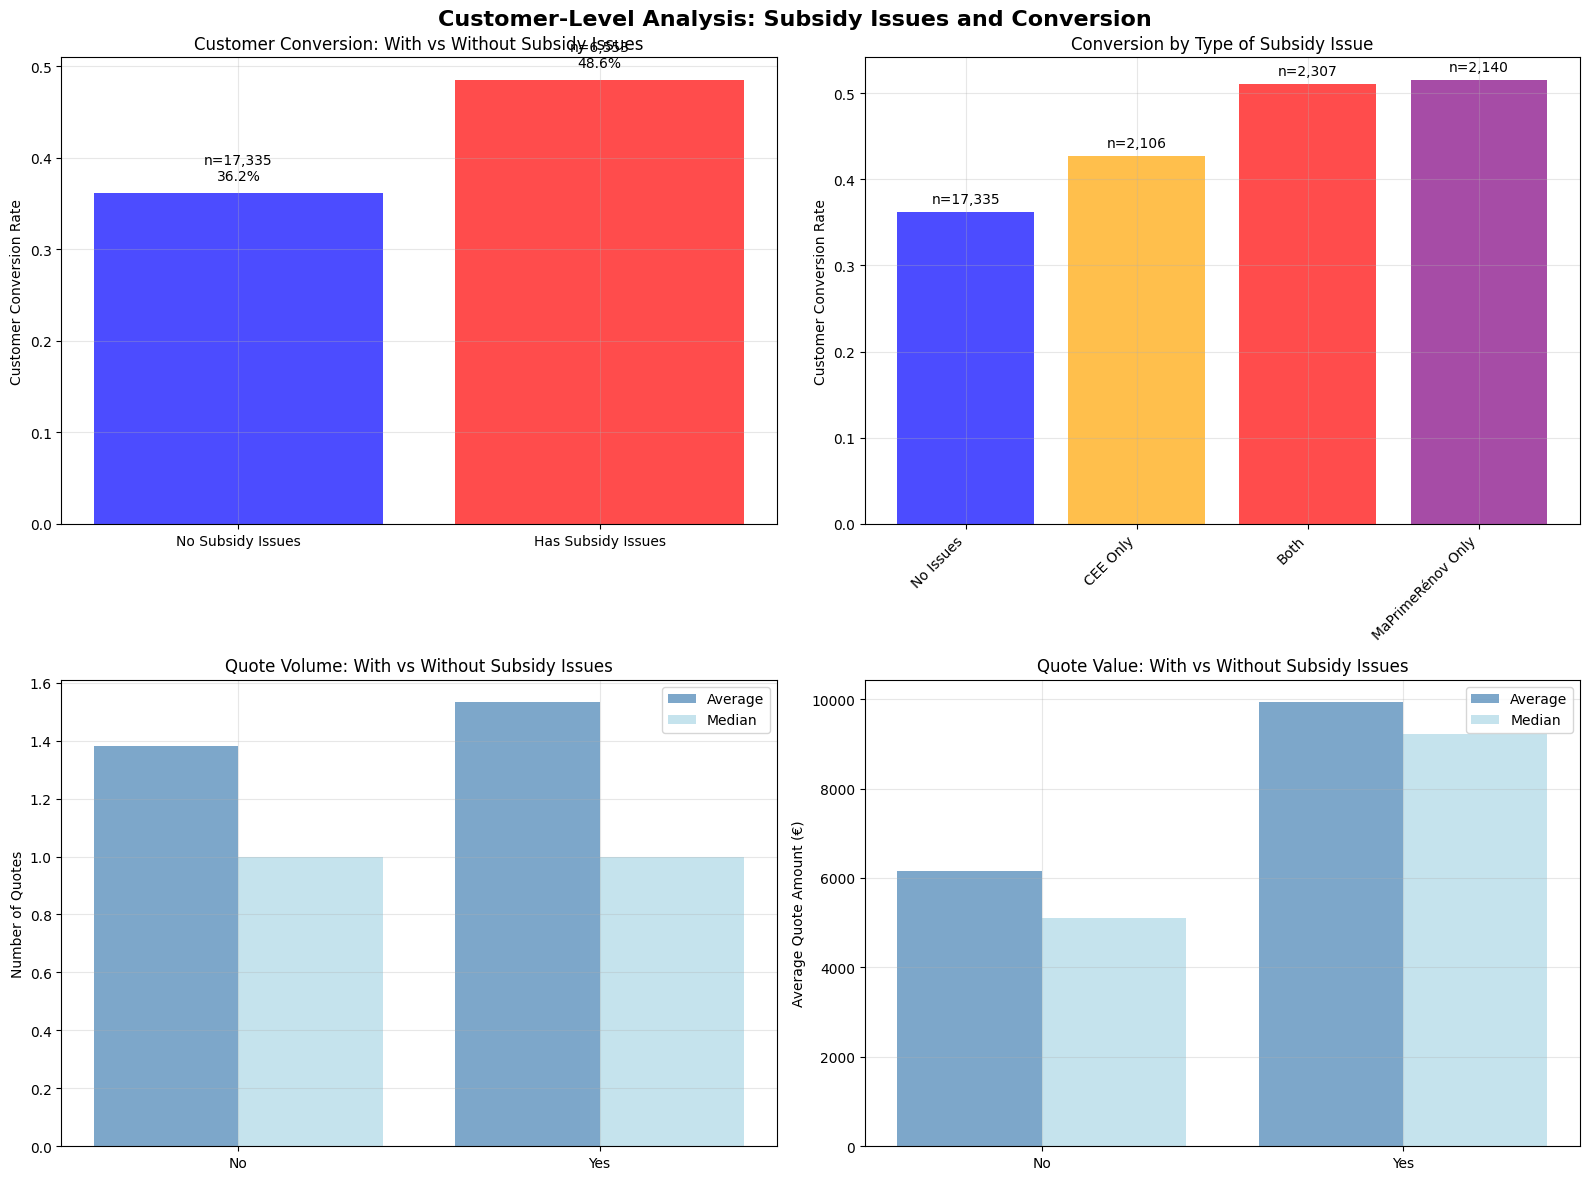


✅ Updated customer dataset saved: 'customer_lifetime_data_with_subsidy.csv'


In [6]:
# VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer-Level Analysis: Subsidy Issues and Conversion', fontsize=16, fontweight='bold')

# Plot 1: Conversion by subsidy issue status
ax1 = axes[0, 0]
bars = ax1.bar(['No Subsidy Issues', 'Has Subsidy Issues'], 
               [conv_no_issue, conv_with_issue],
               color=['blue', 'red'], alpha=0.7)
ax1.set_ylabel('Customer Conversion Rate')
ax1.set_title('Customer Conversion: With vs Without Subsidy Issues')
ax1.grid(True, alpha=0.3)

# Add counts
for i, (bar, (issue, count)) in enumerate(zip(bars, customers.groupby('had_subsidy_issue').size().items())):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'n={count:,}\n{height:.1%}', ha='center', va='bottom')

# Plot 2: Conversion by subsidy issue type
ax2 = axes[0, 1]
type_conv_mean = customers.groupby('subsidy_issue_type')['converted'].mean().sort_values()
type_counts = customers['subsidy_issue_type'].value_counts()
colors = {'No Issues': 'blue', 'CEE Only': 'orange', 'MaPrimeRénov Only': 'purple', 'Both': 'red'}
bar_colors = [colors.get(x, 'gray') for x in type_conv_mean.index]

bars = ax2.bar(range(len(type_conv_mean)), type_conv_mean.values, color=bar_colors, alpha=0.7)
ax2.set_xticks(range(len(type_conv_mean)))
ax2.set_xticklabels(type_conv_mean.index, rotation=45, ha='right')
ax2.set_ylabel('Customer Conversion Rate')
ax2.set_title('Conversion by Type of Subsidy Issue')
ax2.grid(True, alpha=0.3)

for i, (idx, val) in enumerate(type_conv_mean.items()):
    ax2.text(i, val + 0.01, f'n={type_counts[idx]:,}', ha='center')

# Plot 3: Quote volume comparison
ax3 = axes[1, 0]
quote_data = []
for issue in [False, True]:
    subset = customers[customers['had_subsidy_issue'] == issue]
    quote_data.append({
        'Subsidy Issues': 'Yes' if issue else 'No',
        'Avg Quotes': subset['total_quotes'].mean(),
        'Median Quotes': subset['total_quotes'].median()
    })
quote_df = pd.DataFrame(quote_data)

x = range(len(quote_df))
ax3.bar([i - 0.2 for i in x], quote_df['Avg Quotes'], width=0.4, label='Average', alpha=0.7, color='steelblue')
ax3.bar([i + 0.2 for i in x], quote_df['Median Quotes'], width=0.4, label='Median', alpha=0.7, color='lightblue')
ax3.set_xticks(x)
ax3.set_xticklabels(quote_df['Subsidy Issues'])
ax3.set_ylabel('Number of Quotes')
ax3.set_title('Quote Volume: With vs Without Subsidy Issues')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Price comparison
ax4 = axes[1, 1]
price_data = []
for issue in [False, True]:
    subset = customers[customers['had_subsidy_issue'] == issue]
    price_data.append({
        'Subsidy Issues': 'Yes' if issue else 'No',
        'Avg Price': subset['avg_quote_amount'].mean(),
        'Median Price': subset['avg_quote_amount'].median()
    })
price_df = pd.DataFrame(price_data)

x = range(len(price_df))
ax4.bar([i - 0.2 for i in x], price_df['Avg Price'], width=0.4, label='Average', alpha=0.7, color='steelblue')
ax4.bar([i + 0.2 for i in x], price_df['Median Price'], width=0.4, label='Median', alpha=0.7, color='lightblue')
ax4.set_xticks(x)
ax4.set_xticklabels(price_df['Subsidy Issues'])
ax4.set_ylabel('Average Quote Amount (€)')
ax4.set_title('Quote Value: With vs Without Subsidy Issues')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 6: Save the dataset
customers.to_csv('customer_lifetime_data_with_subsidy.csv', index=False)
print("\n✅ Updated customer dataset saved: 'customer_lifetime_data_with_subsidy.csv'")

Unique values in main_product_family:
main_product_family
Chaudière                           7430
Poêle                               5431
Climatisation                       4573
Pompe à chaleur                     4090
ECS : Chauffe-eau ou adoucisseur    1060
Photovoltaïque                       549
Autres                               270
Appareil hybride                     151
Plomberie Sanitaire                  103
Emetteur de chauffage  ou chappe      93
Produit VMC                           89
Unknown                               36
Fumisterie                            13
Name: count, dtype: int64

Top products:
main_product_family
Chaudière                           7430
Poêle                               5431
Climatisation                       4573
Pompe à chaleur                     4090
ECS : Chauffe-eau ou adoucisseur    1060
Photovoltaïque                       549
Autres                               270
Appareil hybride                     151
Plomberie Sanitaire 

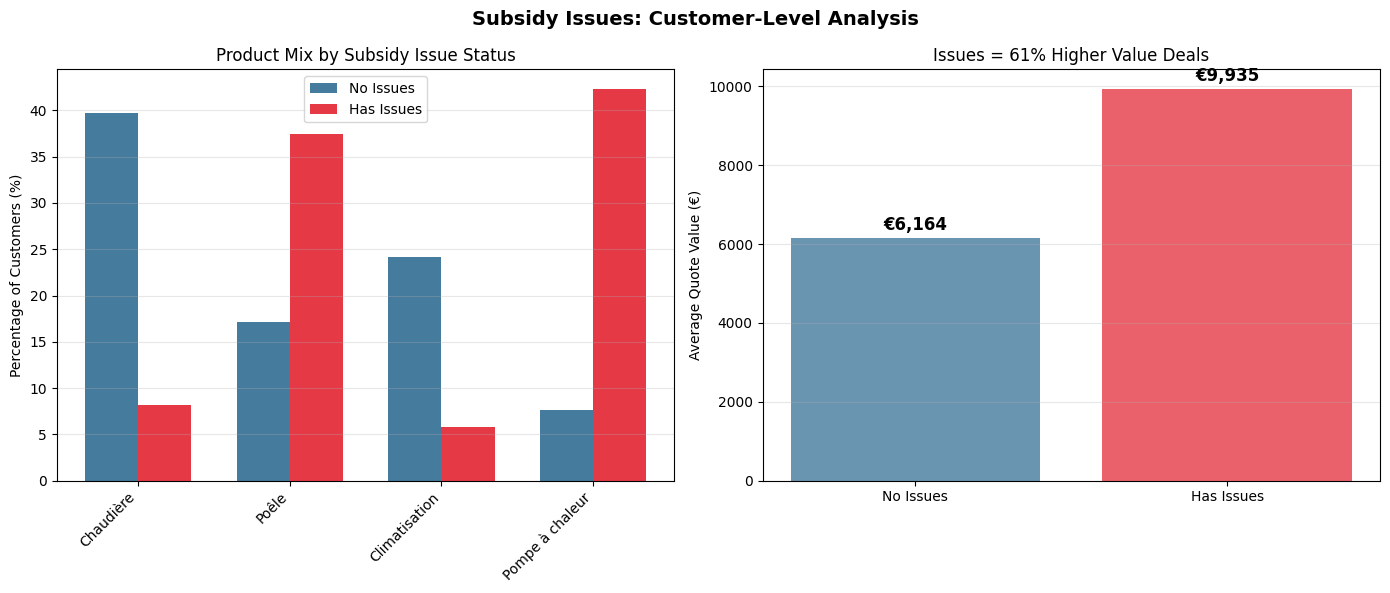

In [7]:
# First, let's see what values actually exist in your data
print("Unique values in main_product_family:")
print(customers['main_product_family'].value_counts())

# Create figure with only 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Subsidy Issues: Customer-Level Analysis', fontsize=14, fontweight='bold')

# Plot 1: Product mix (DYNAMIC) - USING ACTUAL DATA VALUES
ax1 = axes[0]

# Get the top product categories from the actual data
product_counts = customers['main_product_family'].value_counts()
print("\nTop products:")
print(product_counts.head(10))

# Use the actual top products from your data
# Let's take top 4 for clarity
top_products = product_counts.head(4).index.tolist()
print(f"\nUsing these products: {top_products}")

# Calculate percentages for customers WITHOUT subsidy issues
no_issue_customers = customers[~customers['had_subsidy_issue']]
no_issue_pct = []
for product in top_products:
    pct = (no_issue_customers['main_product_family'] == product).mean() * 100
    no_issue_pct.append(pct)

# Calculate percentages for customers WITH subsidy issues
issue_customers = customers[customers['had_subsidy_issue']]
issue_pct = []
for product in top_products:
    pct = (issue_customers['main_product_family'] == product).mean() * 100
    issue_pct.append(pct)

print("\nNo Issue %:", no_issue_pct)
print("Has Issue %:", issue_pct)

x = range(len(top_products))
width = 0.35
ax1.bar([i - width/2 for i in x], no_issue_pct, width, label='No Issues', color='#457b9d')
ax1.bar([i + width/2 for i in x], issue_pct, width, label='Has Issues', color='#e63946')
ax1.set_xticks(x)
ax1.set_xticklabels(top_products, rotation=45, ha='right')
ax1.set_ylabel('Percentage of Customers (%)')
ax1.set_title('Product Mix by Subsidy Issue Status')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Average quote value (DYNAMIC)
ax2 = axes[1]

# Calculate average quote values dynamically
avg_no_issue = customers[~customers['had_subsidy_issue']]['avg_quote_amount'].mean()
avg_with_issue = customers[customers['had_subsidy_issue']]['avg_quote_amount'].mean()
value_diff = (avg_with_issue / avg_no_issue - 1) * 100

bars = ax2.bar(['No Issues', 'Has Issues'], 
               [avg_no_issue, avg_with_issue], 
               color=['#457b9d', '#e63946'], alpha=0.8)
ax2.set_ylabel('Average Quote Value (€)')
ax2.set_title(f'Issues = {value_diff:.0f}% Higher Value Deals')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, [avg_no_issue, avg_with_issue]):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
             f'€{val:,.0f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


HYPOTHESIS 1: THRESHOLD EFFECT (CUSTOMER LEVEL)

Analyzing 23,410 customers
Price range: €1,341 to €28,766
Median price: €6,352


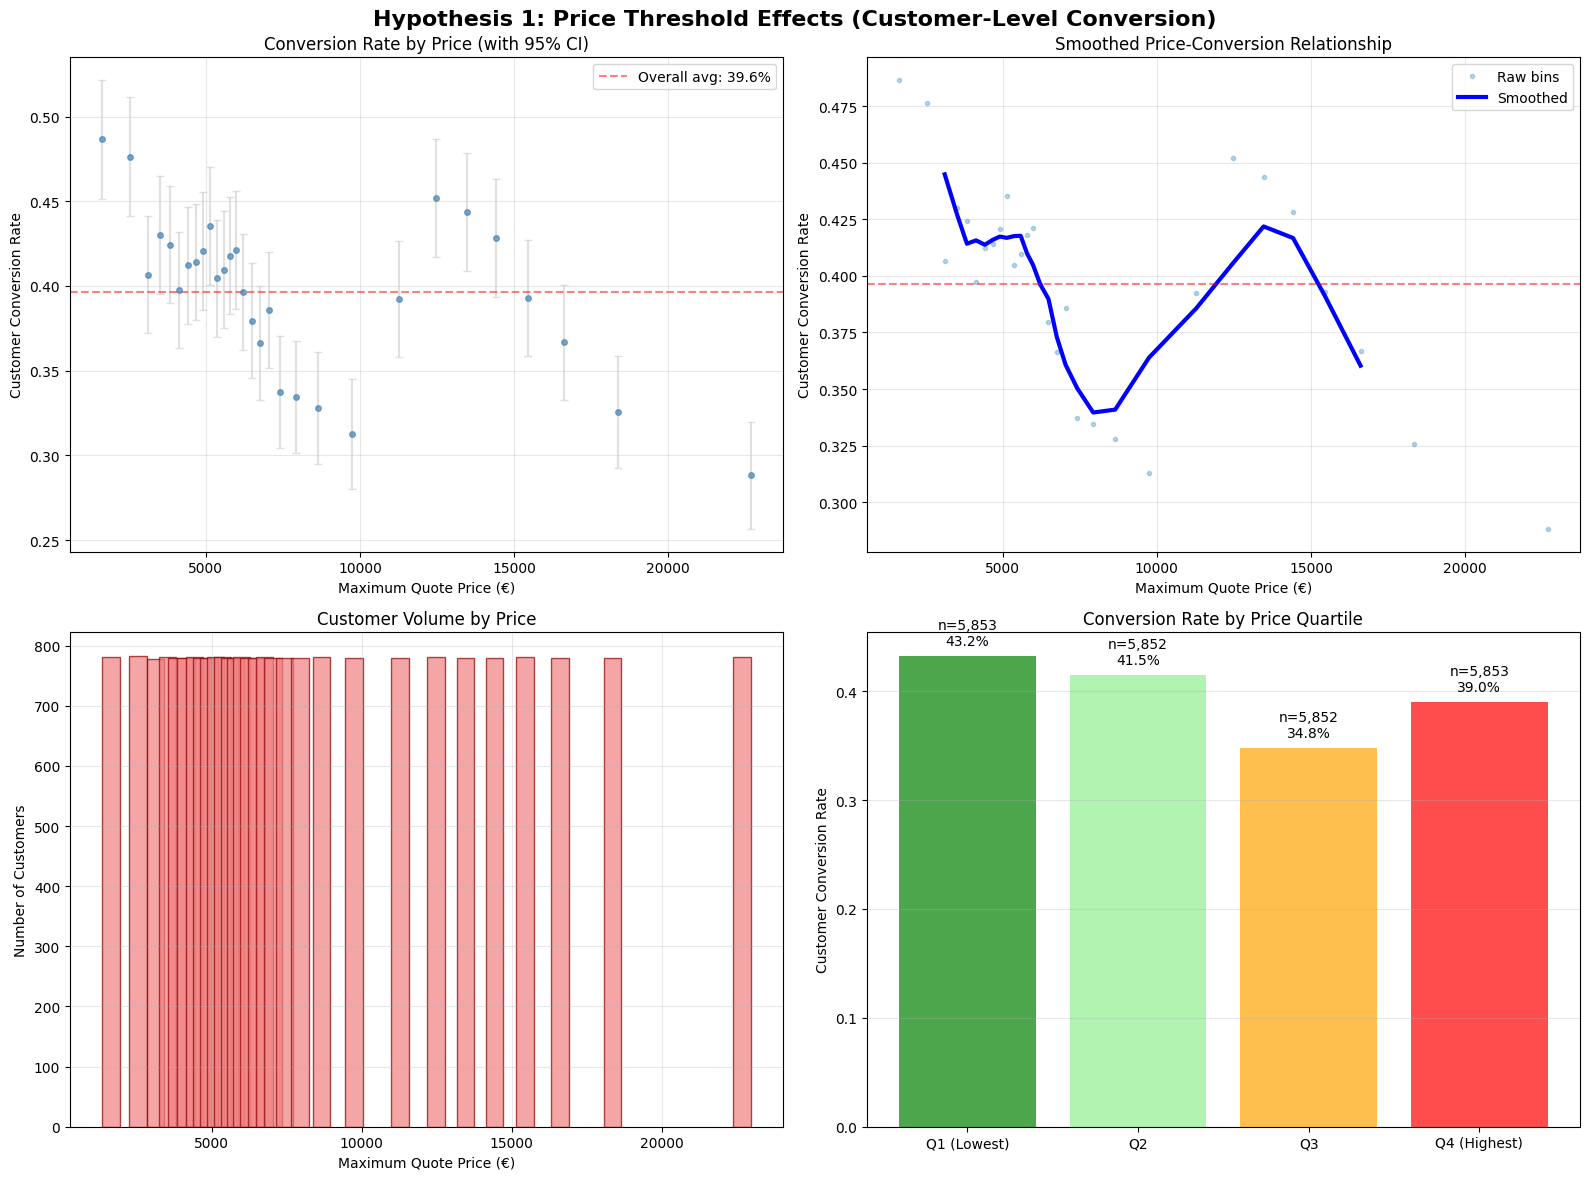


THRESHOLD EFFECT: KEY FINDINGS (CUSTOMER LEVEL)

Conversion by Price Quartile:
  Q1 (Lowest): 43.2% (n=5,853)
  Q2: 41.5% (n=5,852)
  Q3: 34.8% (n=5,852)
  Q4 (Highest): 39.0% (n=5,853)

Difference between lowest and highest quartile: 4.3 percentage points

Sweet spots (above-average conversion):
  €1,645: 48.7% (n=781)
  €2,543: 47.6% (n=783)
  €3,121: 40.7% (n=777)
  €3,524: 43.0% (n=781)
  €3,842: 42.4% (n=780)
  €4,137: 39.7% (n=780)
  €4,423: 41.2% (n=781)
  €4,680: 41.4% (n=780)
  €4,908: 42.0% (n=780)
  €5,133: 43.5% (n=781)
  €5,366: 40.5% (n=781)
  €5,585: 40.9% (n=779)
  €5,792: 41.8% (n=780)
  €5,985: 42.1% (n=781)
  €12,481: 45.2% (n=781)
  €13,464: 44.4% (n=780)
  €14,420: 42.8% (n=780)


In [8]:
print("\n" + "="*80)
print("HYPOTHESIS 1: THRESHOLD EFFECT")
print("="*80)

# Use max_out_of_pocket as the key price variable (highest quote they considered)
price_var = 'max_out_of_pocket'

# Remove extreme outliers for clean visualization
price_lower = customers[price_var].quantile(0.01)
price_upper = customers[price_var].quantile(0.99)
customers_clean = customers[(customers[price_var] >= price_lower) & 
                            (customers[price_var] <= price_upper)].copy()

print(f"\nAnalyzing {len(customers_clean):,} customers")
print(f"Price range: €{customers_clean[price_var].min():,.0f} to €{customers_clean[price_var].max():,.0f}")
print(f"Median price: €{customers_clean[price_var].median():,.0f}")

# Create price bins with equal number of customers
customers_clean['price_bin'] = pd.qcut(customers_clean[price_var], q=30, duplicates='drop')

# Calculate conversion rate per bin
binned_stats = customers_clean.groupby('price_bin').agg({
    'converted': ['mean', 'count', 'sem'],
    price_var: 'mean'
}).round(4)

binned_stats.columns = ['conversion_rate', 'customer_count', 'std_error', 'avg_price']
binned_stats['ci_lower'] = binned_stats['conversion_rate'] - 1.96 * binned_stats['std_error']
binned_stats['ci_upper'] = binned_stats['conversion_rate'] + 1.96 * binned_stats['std_error']
binned_stats = binned_stats.reset_index()

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Hypothesis 1: Price Threshold Effects (Customer-Level Conversion)', fontsize=16, fontweight='bold')

# Plot 1: Binned conversion with confidence intervals
ax1 = axes[0, 0]
ax1.errorbar(binned_stats['avg_price'], binned_stats['conversion_rate'], 
             yerr=1.96*binned_stats['std_error'], 
             fmt='o', color='steelblue', ecolor='lightgray', 
             capsize=3, markersize=4, alpha=0.7)
ax1.axhline(y=customers_clean['converted'].mean(), color='red', 
            linestyle='--', alpha=0.5, label=f"Overall avg: {customers_clean['converted'].mean():.1%}")
ax1.set_xlabel('Maximum Quote Price (€)')
ax1.set_ylabel('Customer Conversion Rate')
ax1.set_title('Conversion Rate by Price (with 95% CI)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Smoothed curve
ax2 = axes[0, 1]
window = 5
smoothed = binned_stats['conversion_rate'].rolling(window=window, center=True).mean()
ax2.plot(binned_stats['avg_price'], binned_stats['conversion_rate'], 
         'o', alpha=0.3, markersize=3, label='Raw bins')
ax2.plot(binned_stats['avg_price'], smoothed, 'b-', linewidth=3, label='Smoothed')
ax2.axhline(y=customers_clean['converted'].mean(), color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Maximum Quote Price (€)')
ax2.set_ylabel('Customer Conversion Rate')
ax2.set_title('Smoothed Price-Conversion Relationship')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Volume distribution
ax3 = axes[1, 0]
ax3.bar(binned_stats['avg_price'], binned_stats['customer_count'], 
        width=np.diff(binned_stats['avg_price']).mean()*0.8,
        color='lightcoral', alpha=0.7, edgecolor='darkred')
ax3.set_xlabel('Maximum Quote Price (€)')
ax3.set_ylabel('Number of Customers')
ax3.set_title('Customer Volume by Price')
ax3.grid(True, alpha=0.3)

# Plot 4: Conversion by price quartile
ax4 = axes[1, 1]
customers_clean['price_quartile'] = pd.qcut(customers_clean[price_var], q=4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])
quartile_conv = customers_clean.groupby('price_quartile')['converted'].mean()
quartile_counts = customers_clean.groupby('price_quartile').size()

bars = ax4.bar(range(4), quartile_conv.values, color=['green', 'lightgreen', 'orange', 'red'], alpha=0.7)
ax4.set_xticks(range(4))
ax4.set_xticklabels(quartile_conv.index)
ax4.set_ylabel('Customer Conversion Rate')
ax4.set_title('Conversion Rate by Price Quartile')
ax4.grid(True, alpha=0.3, axis='y')

for i, (bar, (idx, count)) in enumerate(zip(bars, quartile_counts.items())):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'n={count:,}\n{height:.1%}', ha='center')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("THRESHOLD EFFECT: KEY FINDINGS (CUSTOMER LEVEL)")
print("="*80)

print(f"\nConversion by Price Quartile:")
for i, (quartile, conv) in enumerate(quartile_conv.items()):
    print(f"  {quartile}: {conv:.1%} (n={quartile_counts.iloc[i]:,})")

q1_vs_q4 = quartile_conv.iloc[0] - quartile_conv.iloc[-1]
print(f"\nDifference between lowest and highest quartile: {q1_vs_q4*100:.1f} percentage points")

# Check for sweet spots (where conversion is above average)
above_avg = binned_stats[binned_stats['conversion_rate'] > customers_clean['converted'].mean()]
if len(above_avg) > 0:
    print(f"\nSweet spots (above-average conversion):")
    for _, row in above_avg.iterrows():
        print(f"  €{row['avg_price']:,.0f}: {row['conversion_rate']:.1%} (n={row['customer_count']:,})")

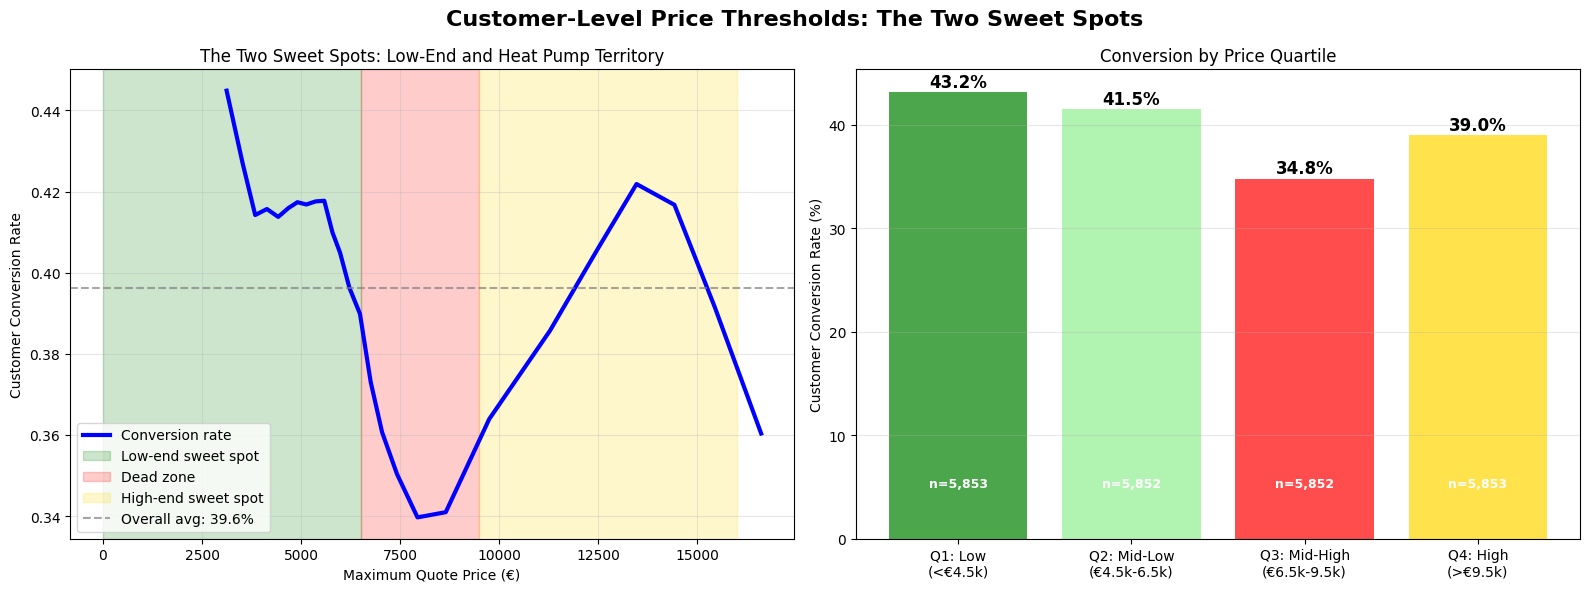

In [9]:
# Let's visualize this clearly
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer-Level Price Thresholds: The Two Sweet Spots', fontsize=16, fontweight='bold')

# Plot 1: Full curve with highlighted regions
ax1 = axes[0]
ax1.plot(binned_stats['avg_price'], smoothed, 'b-', linewidth=3, label='Conversion rate')

# Highlight regions
ax1.axvspan(0, 6500, alpha=0.2, color='green', label='Low-end sweet spot')
ax1.axvspan(6500, 9500, alpha=0.2, color='red', label='Dead zone')
ax1.axvspan(9500, 16000, alpha=0.2, color='gold', label='High-end sweet spot')

# Add overall average line
ax1.axhline(y=customers_clean['converted'].mean(), color='gray', 
            linestyle='--', alpha=0.7, label=f'Overall avg: {customers_clean["converted"].mean():.1%}')

ax1.set_xlabel('Maximum Quote Price (€)')
ax1.set_ylabel('Customer Conversion Rate')
ax1.set_title('The Two Sweet Spots: Low-End and Heat Pump Territory')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Bar chart of quartiles with annotations
ax2 = axes[1]
quartiles = ['Q1: Low\n(<€4.5k)', 'Q2: Mid-Low\n(€4.5k-6.5k)', 
             'Q3: Mid-High\n(€6.5k-9.5k)', 'Q4: High\n(>€9.5k)']
values = [43.2, 41.5, 34.8, 39.0]
colors = ['green', 'lightgreen', 'red', 'gold']

bars = ax2.bar(quartiles, values, color=colors, alpha=0.7)
ax2.set_ylabel('Customer Conversion Rate (%)')
ax2.set_title('Conversion by Price Quartile')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=12, fontweight='bold')

# Add sample sizes
sample_sizes = [5853, 5852, 5852, 5853]
for i, (bar, n) in enumerate(zip(bars, sample_sizes)):
    ax2.text(bar.get_x() + bar.get_width()/2., 5,
             f'n={n:,}', ha='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# Create price quartiles in the customer dataset
customers_clean['price_quartile'] = pd.qcut(customers_clean['max_out_of_pocket'], 
                                             q=4, labels=['Q1_Low', 'Q2_MidLow', 'Q3_MidHigh', 'Q4_High'])

# Analyze product mix by quartile
print("\n" + "="*80)
print("PRODUCT MIX BY PRICE QUARTILE")
print("="*80)

product_by_quartile = pd.crosstab(
    customers_clean['price_quartile'], 
    customers_clean['main_equipment_category'],
    normalize='index'
) * 100

print("\nProduct distribution by price quartile (%):")
print(product_by_quartile.round(1))

# Conversion by product and quartile
print("\n" + "="*80)
print("CONVERSION BY PRODUCT AND PRICE QUARTILE")
print("="*80)

for product in ['Heat Pump', 'Boiler', 'AC', 'Stove']:
    subset = customers_clean[customers_clean['main_equipment_category'] == product]
    if len(subset) > 100:
        print(f"\n{product} (n={len(subset):,}):")
        quartile_conv = subset.groupby('price_quartile')['converted'].mean() * 100
        for quartile, conv in quartile_conv.items():
            print(f"  {quartile}: {conv:.1f}%")

# Heat pump specific analysis
hp_customers = customers_clean[customers_clean['ever_bought_heat_pump']]
print("\n" + "="*80)
print("HEAT PUMP CUSTOMERS (n={:,})".format(len(hp_customers)))
print("="*80)

print(f"Average price: €{hp_customers['max_out_of_pocket'].mean():,.0f}")
print(f"Conversion rate: {hp_customers['converted'].mean():.1%}")
print(f"Subsidy issue rate: {hp_customers['had_subsidy_issue'].mean():.1%}")

# Where do heat pumps appear?
hp_by_quartile = customers_clean.groupby('price_quartile')['ever_bought_heat_pump'].mean() * 100
print("\nHeat pump adoption by quartile:")
for quartile, pct in hp_by_quartile.items():
    print(f"  {quartile}: {pct:.1f}%")


PRODUCT MIX BY PRICE QUARTILE

Product distribution by price quartile (%):
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove  Unknown
price_quartile                                                         
Q1_Low                   24.7    45.8        1.3   16.3   11.8      0.1
Q2_MidLow                14.7    35.5        0.8    2.4   46.5      0.1
Q3_MidHigh               25.3    30.9        5.4    5.7   32.5      0.1
Q4_High                  13.9    12.2       65.0    6.8    1.9      0.2

CONVERSION BY PRODUCT AND PRICE QUARTILE

Heat Pump (n=4,248):
  Q1_Low: 49.4%
  Q2_MidLow: 34.7%
  Q3_MidHigh: 52.2%
  Q4_High: 42.4%

Boiler (n=7,282):
  Q1_Low: 46.0%
  Q2_MidLow: 40.8%
  Q3_MidHigh: 38.7%
  Q4_High: 36.6%

AC (n=4,597):
  Q1_Low: 36.7%
  Q2_MidLow: 30.7%
  Q3_MidHigh: 27.8%
  Q4_High: 31.9%

Stove (n=5,419):
  Q1_Low: 47.7%
  Q2_MidLow: 45.9%
  Q3_MidHigh: 34.9%
  Q4_High: 31.2%

HEAT PUMP CUSTOMERS (n=4,711)
Average price: €15,179
Conversion rate: 43.1%
Subsidy iss


HYPOTHESIS 2: SEGMENT EFFECT (CUSTOMER LEVEL)


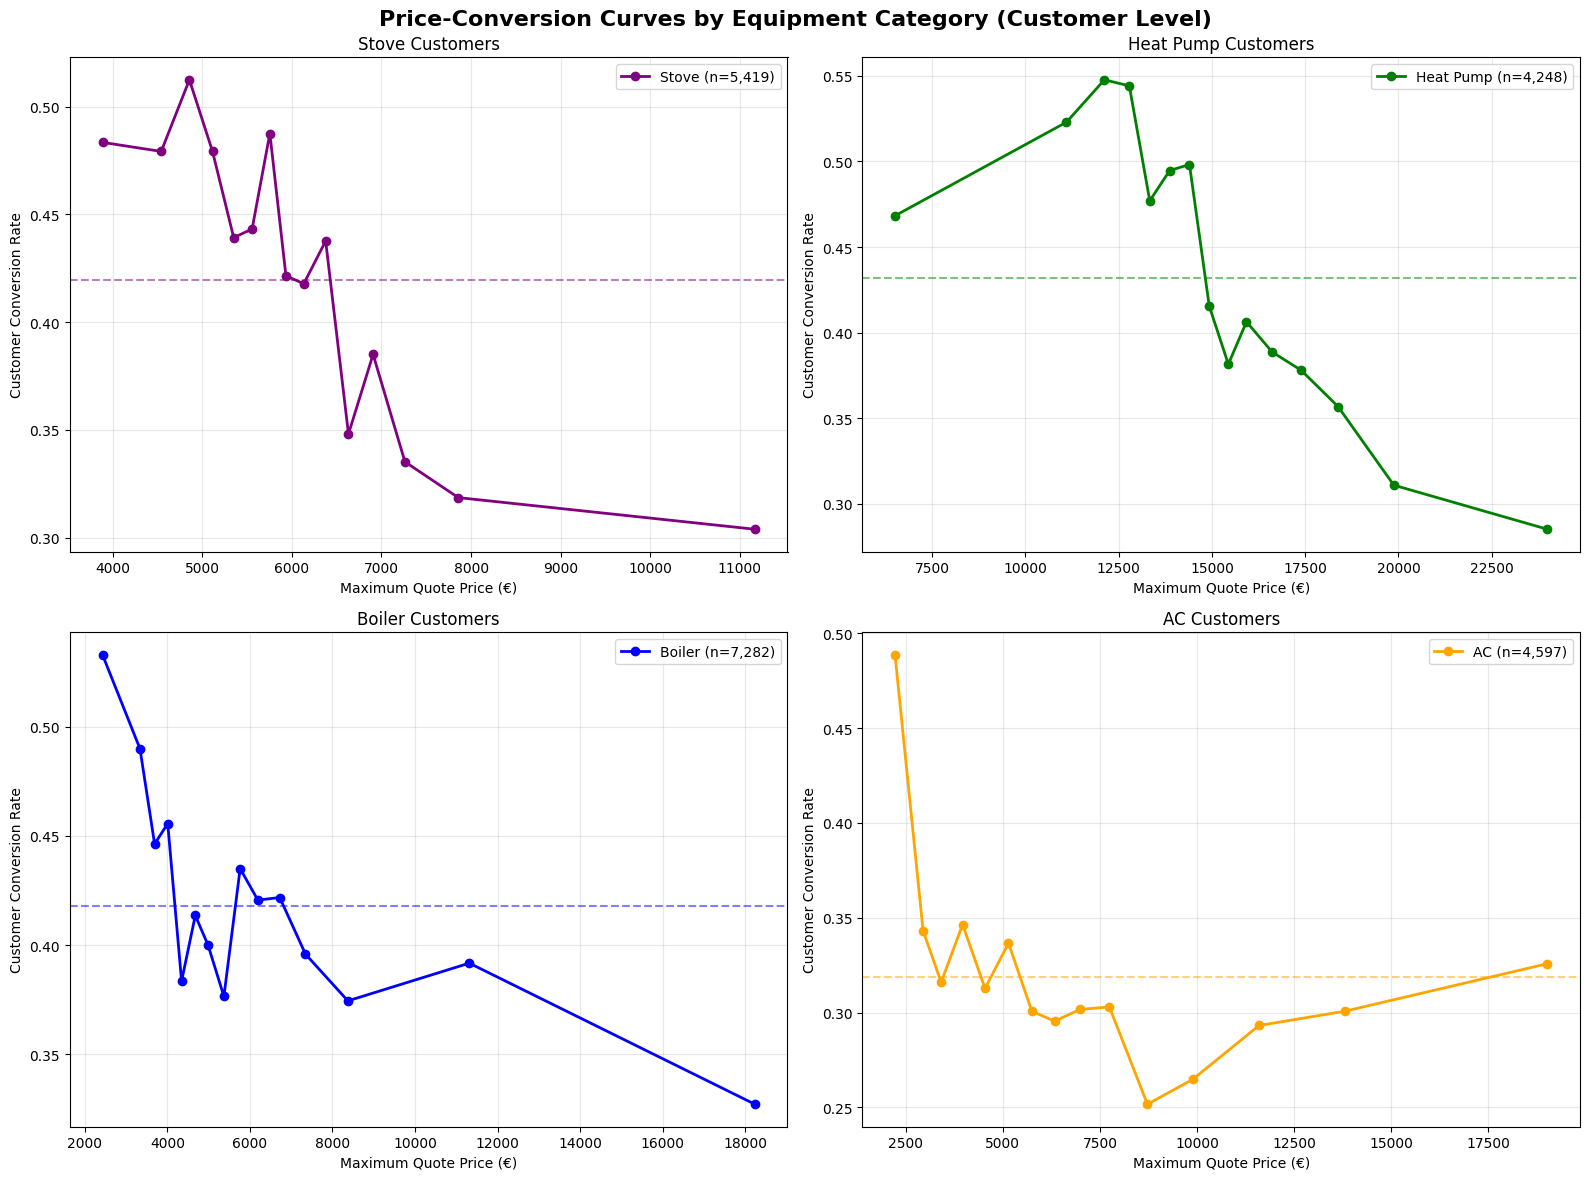

In [11]:
print("\n" + "="*80)
print("HYPOTHESIS 2: SEGMENT EFFECT (CUSTOMER LEVEL)")
print("="*80)

# Segment 1: By equipment category
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Price-Conversion Curves by Equipment Category (Customer Level)', fontsize=16, fontweight='bold')

products = ['Stove', 'Heat Pump', 'Boiler', 'AC']
colors = ['purple', 'green', 'blue', 'orange']

for idx, (product, color) in enumerate(zip(products, colors)):
    ax = axes[idx // 2, idx % 2]
    
    subset = customers_clean[customers_clean['main_equipment_category'] == product]
    if len(subset) > 200:
        # Create price bins
        subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=15, duplicates='drop')
        bin_conv = subset.groupby('price_bin')['converted'].mean()
        bin_price = subset.groupby('price_bin')['max_out_of_pocket'].mean()
        
        ax.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, 
                label=f'{product} (n={len(subset):,})')
        ax.axhline(y=subset['converted'].mean(), color=color, linestyle='--', alpha=0.5)
        
    ax.set_xlabel('Maximum Quote Price (€)')
    ax.set_ylabel('Customer Conversion Rate')
    ax.set_title(f'{product} Customers')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

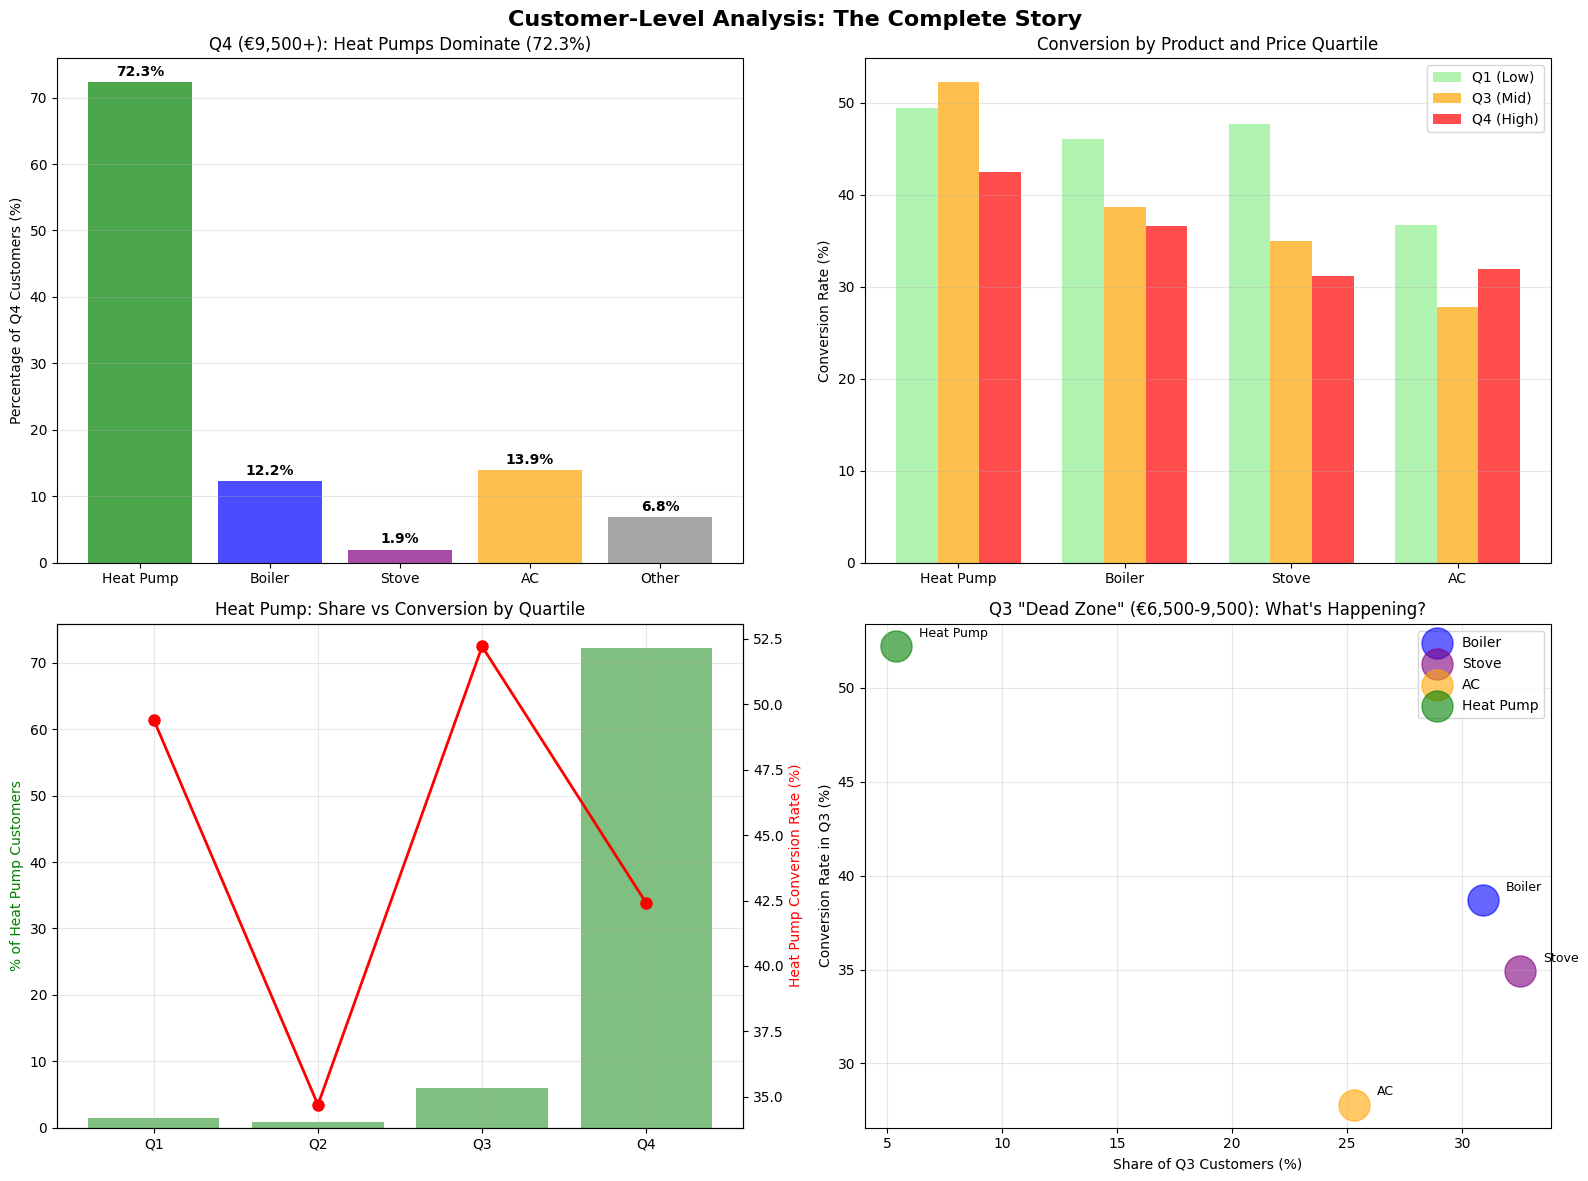

In [12]:
# Create a comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer-Level Analysis: The Complete Story', fontsize=16, fontweight='bold')

# Plot 1: Heat pump dominance in Q4
ax1 = axes[0, 0]
products = ['Heat Pump', 'Boiler', 'Stove', 'AC', 'Other']
q4_shares = [72.3, 12.2, 1.9, 13.9, 6.8]
colors = ['green', 'blue', 'purple', 'orange', 'gray']
bars = ax1.bar(products, q4_shares, color=colors, alpha=0.7)
ax1.set_ylabel('Percentage of Q4 Customers (%)')
ax1.set_title('Q4 (€9,500+): Heat Pumps Dominate (72.3%)')
ax1.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, q4_shares):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val}%', ha='center', fontweight='bold')

# Plot 2: Conversion by product and quartile
ax2 = axes[0, 1]
products = ['Heat Pump', 'Boiler', 'Stove', 'AC']
x = range(len(products))
q1_conv = [49.4, 46.0, 47.7, 36.7]
q3_conv = [52.2, 38.7, 34.9, 27.8]
q4_conv = [42.4, 36.6, 31.2, 31.9]

width = 0.25
ax2.bar([i - width for i in x], q1_conv, width, label='Q1 (Low)', color='lightgreen', alpha=0.7)
ax2.bar([i for i in x], q3_conv, width, label='Q3 (Mid)', color='orange', alpha=0.7)
ax2.bar([i + width for i in x], q4_conv, width, label='Q4 (High)', color='red', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(products)
ax2.set_ylabel('Conversion Rate (%)')
ax2.set_title('Conversion by Product and Price Quartile')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: The heat pump story
ax3 = axes[1, 0]
quartiles = ['Q1', 'Q2', 'Q3', 'Q4']
hp_share = [1.4, 0.9, 6.0, 72.3]
hp_conv = [49.4, 34.7, 52.2, 42.4]

ax3_twin = ax3.twinx()
bars = ax3.bar(quartiles, hp_share, color='green', alpha=0.5, label='% of Heat Pumps')
ax3.set_ylabel('% of Heat Pump Customers', color='green')
ax3_twin.plot(quartiles, hp_conv, 'ro-', linewidth=2, markersize=8, label='Conversion')
ax3_twin.set_ylabel('Heat Pump Conversion Rate (%)', color='red')
ax3.set_title('Heat Pump: Share vs Conversion by Quartile')
ax3.grid(True, alpha=0.3)

# Plot 4: The dead zone explained
ax4 = axes[1, 1]
products = ['Boiler', 'Stove', 'AC', 'Heat Pump']
q3_shares = [30.9, 32.5, 25.3, 5.4]
q3_conv_all = [38.7, 34.9, 27.8, 52.2]
colors = ['blue', 'purple', 'orange', 'green']

for i, (product, share, conv, color) in enumerate(zip(products, q3_shares, q3_conv_all, colors)):
    ax4.scatter(share, conv, s=500, color=color, alpha=0.6, label=f'{product}')
    ax4.text(share+1, conv+0.5, f'{product}', fontsize=9)

ax4.set_xlabel('Share of Q3 Customers (%)')
ax4.set_ylabel('Conversion Rate in Q3 (%)')
ax4.set_title('Q3 "Dead Zone" (€6,500-9,500): What\'s Happening?')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

In [13]:
print("\n" + "="*80)
print("HYPOTHESIS 3: CONTEXT/SEASONAL EFFECT (CUSTOMER LEVEL)")
print("="*80)

# First, ensure we have date information at customer level
# We need to add season/quarter based on first_quote_date
customers_clean['first_quote_date'] = pd.to_datetime(customers_clean['first_quote_date'])
customers_clean['year'] = customers_clean['first_quote_date'].dt.year
customers_clean['month'] = customers_clean['first_quote_date'].dt.month
customers_clean['quarter'] = customers_clean['first_quote_date'].dt.quarter

# Create season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

customers_clean['season'] = customers_clean['month'].apply(get_season)

# Add policy context (subsidy suspensions)
customers_clean['during_suspension'] = (
    (customers_clean['first_quote_date'] >= '2025-07-01') & 
    (customers_clean['first_quote_date'] <= '2025-09-30')
) | (
    (customers_clean['first_quote_date'] >= '2026-01-01') & 
    (customers_clean['first_quote_date'] <= '2026-01-22')
)

print(f"\nDate range: {customers_clean['first_quote_date'].min()} to {customers_clean['first_quote_date'].max()}")
print(f"Customers during suspension periods: {customers_clean['during_suspension'].sum():,} ({customers_clean['during_suspension'].mean():.1%})")


HYPOTHESIS 3: CONTEXT/SEASONAL EFFECT (CUSTOMER LEVEL)

Date range: 2023-01-02 00:00:00 to 2026-01-22 00:00:00
Customers during suspension periods: 2,993 (12.8%)


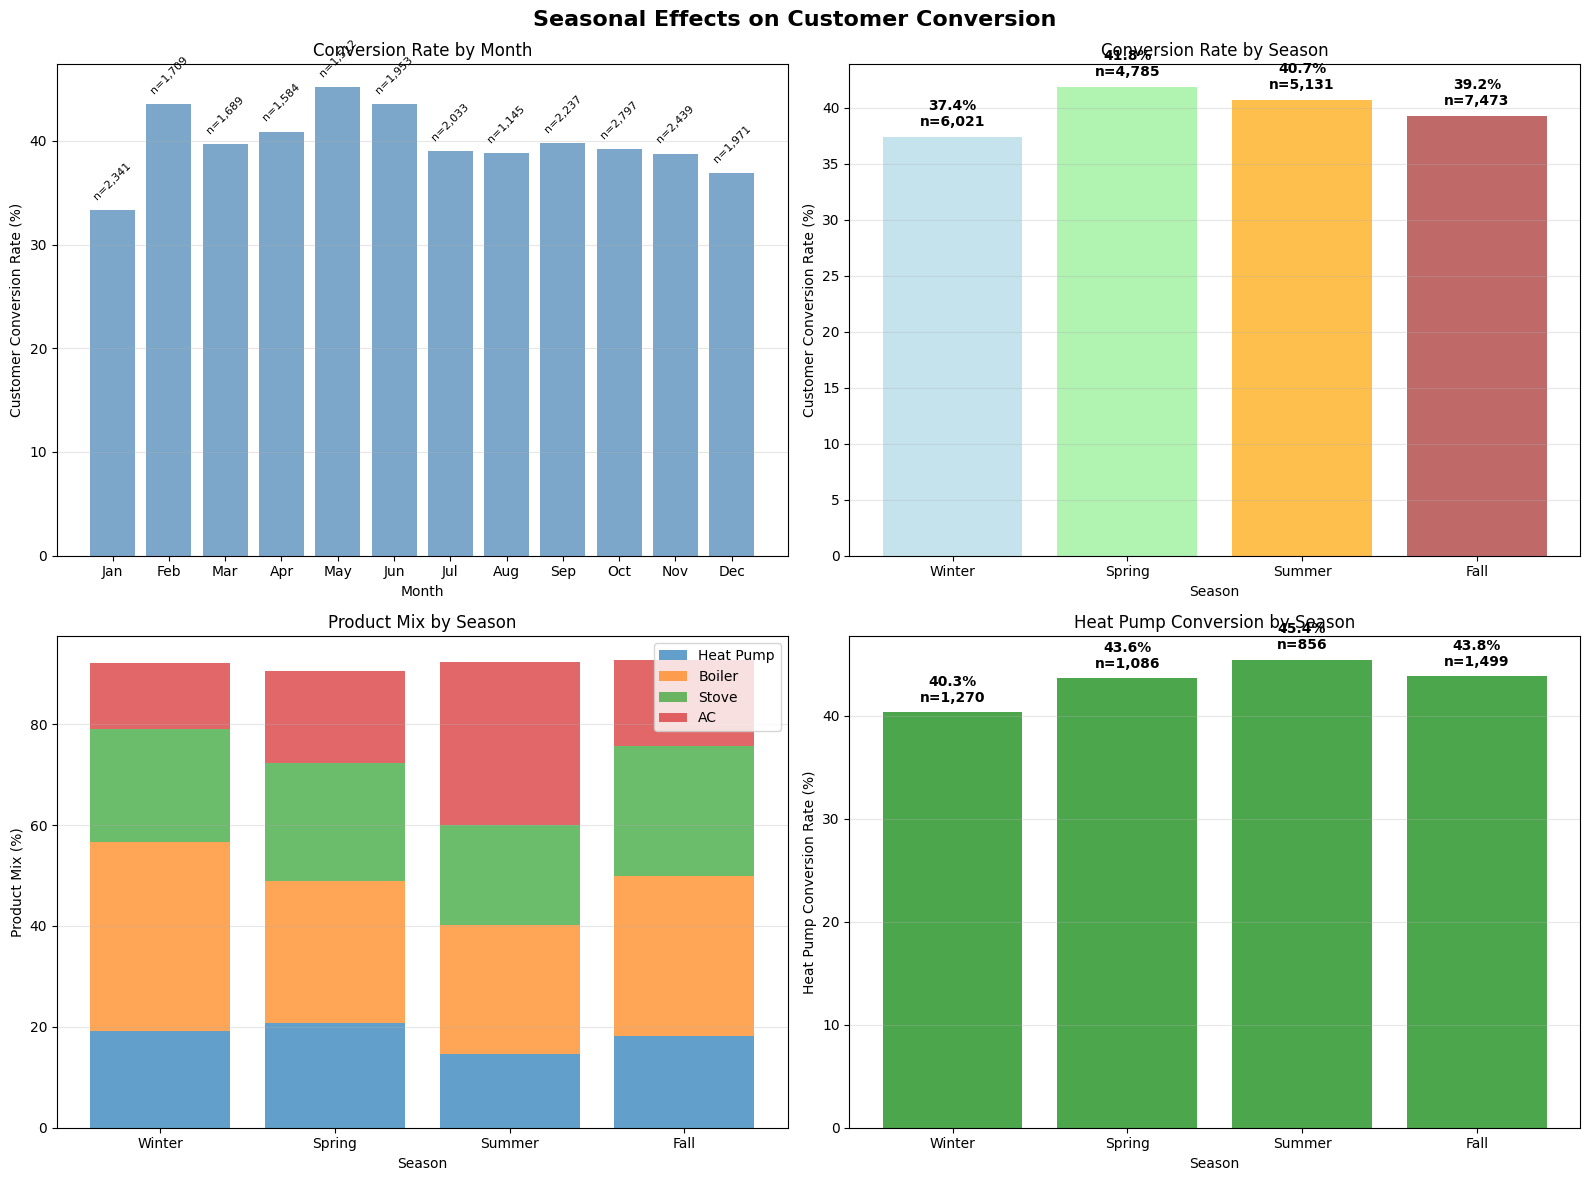


SEASONAL STATISTICS

Conversion by season:
  Winter: 37.4% (n=6,021)
  Spring: 41.8% (n=4,785)
  Summer: 40.7% (n=5,131)
  Fall: 39.2% (n=7,473)

Seasonality chi-square p-value: 0.000014
Statistically significant: YES


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Seasonal Effects on Customer Conversion', fontsize=16, fontweight='bold')

# Plot 1: Conversion by month
ax1 = axes[0, 0]
monthly_conv = customers_clean.groupby('month')['converted'].agg(['mean', 'count'])
monthly_conv = monthly_conv.reindex(range(1, 13))  # Ensure all months show

bars = ax1.bar(monthly_conv.index, monthly_conv['mean'] * 100, 
               color='steelblue', alpha=0.7)
ax1.set_xlabel('Month')
ax1.set_ylabel('Customer Conversion Rate (%)')
ax1.set_title('Conversion Rate by Month')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax1.grid(True, alpha=0.3, axis='y')

# Add sample sizes
for i, (month, row) in enumerate(monthly_conv.iterrows()):
    ax1.text(month, row['mean']*100 + 1, f'n={int(row["count"]):,}', 
             ha='center', fontsize=8, rotation=45)

# Plot 2: Conversion by season
ax2 = axes[0, 1]
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal_conv = customers_clean.groupby('season')['converted'].agg(['mean', 'count'])
seasonal_conv = seasonal_conv.reindex(season_order)

bars = ax2.bar(season_order, seasonal_conv['mean'] * 100, 
               color=['lightblue', 'lightgreen', 'orange', 'brown'], alpha=0.7)
ax2.set_xlabel('Season')
ax2.set_ylabel('Customer Conversion Rate (%)')
ax2.set_title('Conversion Rate by Season')
ax2.grid(True, alpha=0.3, axis='y')

for bar, (season, row) in zip(bars, seasonal_conv.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{row["mean"]*100:.1f}%\nn={int(row["count"]):,}', 
             ha='center', fontweight='bold')

# Plot 3: Product mix by season
ax3 = axes[1, 0]
products = ['Heat Pump', 'Boiler', 'Stove', 'AC']
season_data = []

for season in season_order:
    subset = customers_clean[customers_clean['season'] == season]
    product_shares = []
    for product in products:
        share = (subset['main_equipment_category'] == product).mean() * 100
        product_shares.append(share)
    season_data.append(product_shares)

season_data = np.array(season_data).T

bottom = np.zeros(len(season_order))
for i, (product, shares) in enumerate(zip(products, season_data)):
    ax3.bar(season_order, shares, bottom=bottom, label=product, alpha=0.7)
    bottom += shares

ax3.set_xlabel('Season')
ax3.set_ylabel('Product Mix (%)')
ax3.set_title('Product Mix by Season')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Heat pump conversion by season
ax4 = axes[1, 1]
hp_seasonal = customers_clean[customers_clean['ever_bought_heat_pump']].groupby('season')['converted'].agg(['mean', 'count'])
hp_seasonal = hp_seasonal.reindex(season_order)

bars = ax4.bar(season_order, hp_seasonal['mean'] * 100, 
               color='green', alpha=0.7)
ax4.set_xlabel('Season')
ax4.set_ylabel('Heat Pump Conversion Rate (%)')
ax4.set_title('Heat Pump Conversion by Season')
ax4.grid(True, alpha=0.3, axis='y')

for bar, (season, row) in zip(bars, hp_seasonal.iterrows()):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{row["mean"]*100:.1f}%\nn={int(row["count"]):,}', 
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*80)
print("SEASONAL STATISTICS")
print("="*80)

print("\nConversion by season:")
for season in season_order:
    subset = customers_clean[customers_clean['season'] == season]
    print(f"  {season}: {subset['converted'].mean():.1%} (n={len(subset):,})")

# Statistical test for seasonality
from scipy.stats import chi2_contingency
season_contingency = pd.crosstab(customers_clean['season'], customers_clean['converted'])
chi2, p_value, dof, expected = chi2_contingency(season_contingency)
print(f"\nSeasonality chi-square p-value: {p_value:.6f}")
print(f"Statistically significant: {'YES' if p_value < 0.05 else 'NO'}")


POLICY SUSPENSION IMPACT

Conversion during subsidy suspensions:
                       mean  count
Normal Periods     0.407846  20417
During Suspension  0.317073   2993

Suspension impact p-value: 0.0000
Statistically significant: YES

Product mix during suspensions:
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove  Unknown
during_suspension                                                      
False                    17.0    31.6       19.2    8.0   24.0      0.2
True                     37.4    27.7       11.0    6.2   17.7      0.0


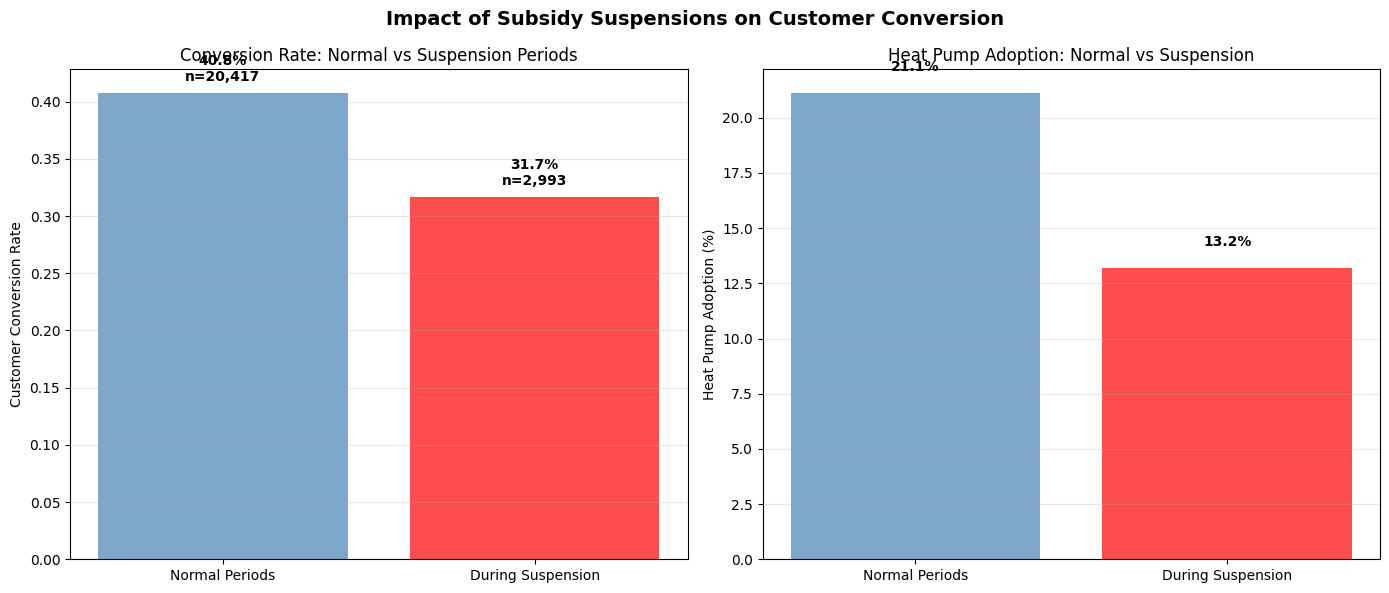

In [15]:
print("\n" + "="*80)
print("POLICY SUSPENSION IMPACT")
print("="*80)

# Compare conversion during vs outside suspensions
susp_conv = customers_clean.groupby('during_suspension')['converted'].agg(['mean', 'count'])
susp_conv.index = ['Normal Periods', 'During Suspension']
print("\nConversion during subsidy suspensions:")
print(susp_conv)

# Statistical test
susp_contingency = pd.crosstab(customers_clean['during_suspension'], customers_clean['converted'])
chi2, p_value, dof, expected = chi2_contingency(susp_contingency)
print(f"\nSuspension impact p-value: {p_value:.4f}")
print(f"Statistically significant: {'YES' if p_value < 0.05 else 'NO'}")

# Check if product mix shifts during suspensions
print("\nProduct mix during suspensions:")
product_mix_susp = pd.crosstab(
    customers_clean['during_suspension'], 
    customers_clean['main_equipment_category'],
    normalize='index'
) * 100
print(product_mix_susp.round(1))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Impact of Subsidy Suspensions on Customer Conversion', fontsize=14, fontweight='bold')

# Plot 1: Conversion comparison
ax1 = axes[0]
bars = ax1.bar(['Normal Periods', 'During Suspension'], 
               [susp_conv.loc['Normal Periods', 'mean'], susp_conv.loc['During Suspension', 'mean']],
               color=['steelblue', 'red'], alpha=0.7)
ax1.set_ylabel('Customer Conversion Rate')
ax1.set_title('Conversion Rate: Normal vs Suspension Periods')
ax1.grid(True, alpha=0.3, axis='y')

for bar, (period, row) in zip(bars, susp_conv.iterrows()):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{row["mean"]:.1%}\nn={int(row["count"]):,}', 
             ha='center', fontweight='bold')

# Plot 2: Heat pump adoption during suspensions
ax2 = axes[1]
hp_susp = customers_clean.groupby('during_suspension')['ever_bought_heat_pump'].mean() * 100
bars = ax2.bar(['Normal Periods', 'During Suspension'], hp_susp.values,
               color=['steelblue', 'red'], alpha=0.7)
ax2.set_ylabel('Heat Pump Adoption (%)')
ax2.set_title('Heat Pump Adoption: Normal vs Suspension')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, hp_susp.values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


YEAR-OVER-YEAR TRENDS

Quarterly conversion rates:
                  mean  count
year_quarter                 
2023Q1        0.445618    947
2023Q2        0.479371   1018
2023Q3        0.443930   1079
2023Q4        0.408221   1776
2024Q1        0.413694   1738
2024Q2        0.445141   1914
2024Q3        0.406745   1957
2024Q4        0.418774   2610
2025Q1        0.393443   2440
2025Q2        0.397260   2117
2025Q3        0.358974   2379
2025Q4        0.337469   2821
2026Q1        0.154723    614


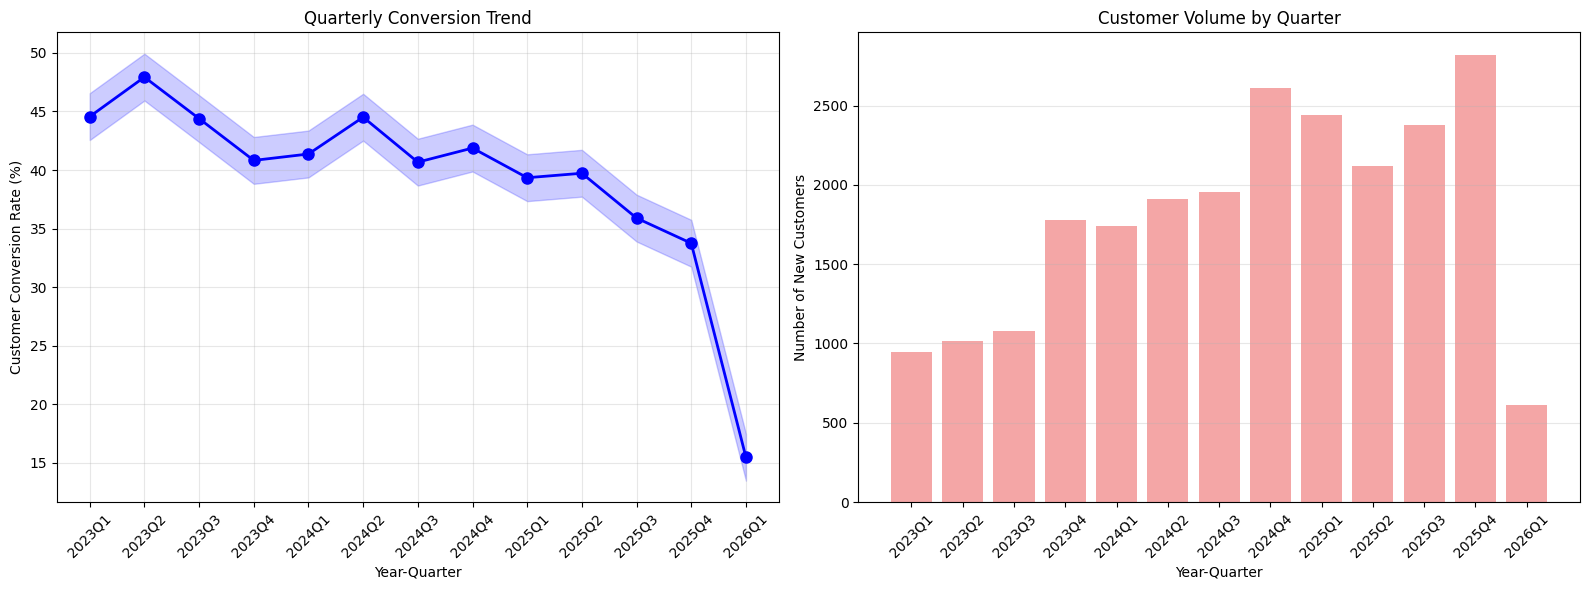

In [16]:
print("\n" + "="*80)
print("YEAR-OVER-YEAR TRENDS")
print("="*80)

# Group by year and quarter
customers_clean['year_quarter'] = customers_clean['first_quote_date'].dt.to_period('Q')
yearly_trend = customers_clean.groupby('year_quarter')['converted'].agg(['mean', 'count'])

print("\nQuarterly conversion rates:")
print(yearly_trend)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Quarterly trend
ax1 = axes[0]
quarters = [str(q) for q in yearly_trend.index]
values = yearly_trend['mean'] * 100

ax1.plot(quarters, values, 'bo-', linewidth=2, markersize=8)
ax1.fill_between(quarters, values - 2, values + 2, alpha=0.2, color='blue')
ax1.set_xlabel('Year-Quarter')
ax1.set_ylabel('Customer Conversion Rate (%)')
ax1.set_title('Quarterly Conversion Trend')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Volume trend
ax2 = axes[1]
volumes = yearly_trend['count'].values
ax2.bar(quarters, volumes, color='lightcoral', alpha=0.7)
ax2.set_xlabel('Year-Quarter')
ax2.set_ylabel('Number of New Customers')
ax2.set_title('Customer Volume by Quarter')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


REGIONAL SEASONAL PATTERNS

Top regions: ['Normandie', 'Auvergne-Rhône-Alpes', 'Île-de-France']


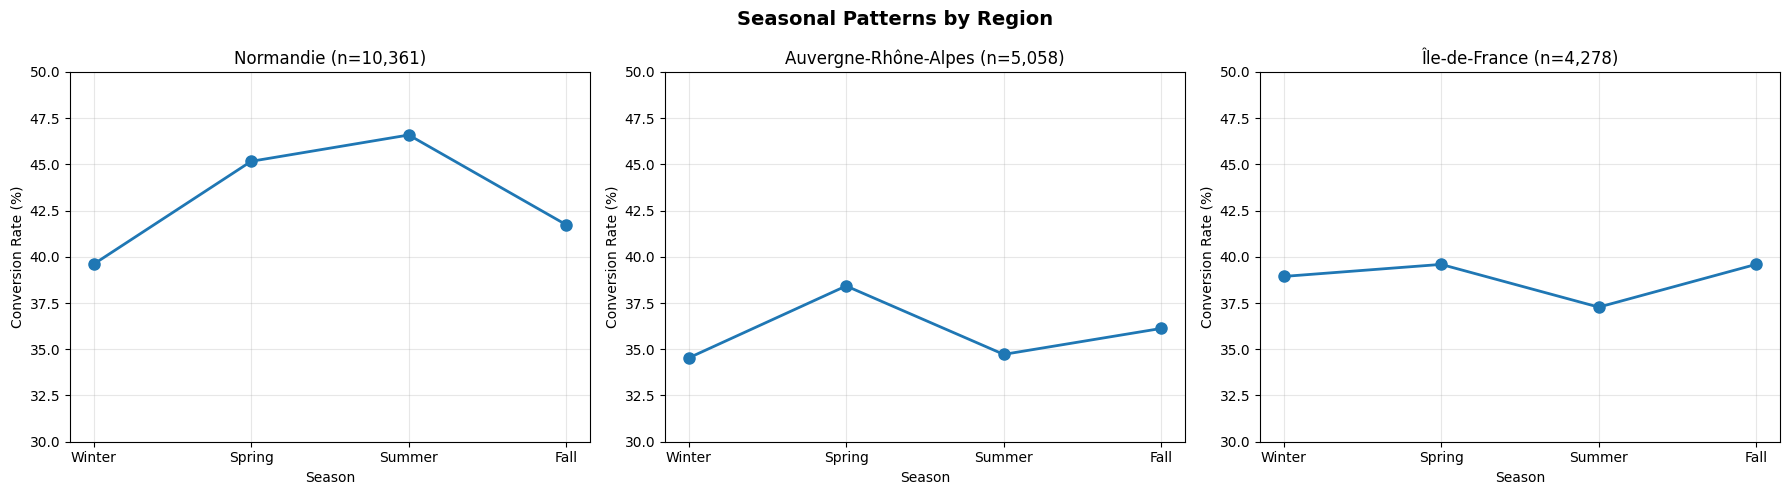

In [17]:
print("\n" + "="*80)
print("REGIONAL SEASONAL PATTERNS")
print("="*80)

# Focus on top regions
top_regions = customers_clean['main_region'].value_counts().head(3).index.tolist()
print(f"\nTop regions: {top_regions}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Seasonal Patterns by Region', fontsize=14, fontweight='bold')

for idx, region in enumerate(top_regions):
    ax = axes[idx]
    subset = customers_clean[customers_clean['main_region'] == region]
    
    seasonal = subset.groupby('season')['converted'].mean() * 100
    seasonal = seasonal.reindex(season_order)
    
    ax.plot(season_order, seasonal.values, 'o-', linewidth=2, markersize=8)
    ax.set_ylim(30, 50)
    ax.set_xlabel('Season')
    ax.set_ylabel('Conversion Rate (%)')
    ax.set_title(f'{region} (n={len(subset):,})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
print("\n" + "="*80)
print("HYPOTHESIS 3: KEY FINDINGS SUMMARY")
print("="*80)

# Best and worst months
monthly_stats = customers_clean.groupby('month')['converted'].agg(['mean', 'count'])
best_month = monthly_stats['mean'].idxmax()
worst_month = monthly_stats['mean'].idxmin()
print(f"\nBest month: {best_month} ({monthly_stats.loc[best_month, 'mean']:.1%}, n={monthly_stats.loc[best_month, 'count']:.0f})")
print(f"Worst month: {worst_month} ({monthly_stats.loc[worst_month, 'mean']:.1%}, n={monthly_stats.loc[worst_month, 'count']:.0f})")

# Best and worst seasons
seasonal_stats = customers_clean.groupby('season')['converted'].agg(['mean', 'count'])
best_season = seasonal_stats['mean'].idxmax()
worst_season = seasonal_stats['mean'].idxmin()
print(f"\nBest season: {best_season} ({seasonal_stats.loc[best_season, 'mean']:.1%})")
print(f"Worst season: {worst_season} ({seasonal_stats.loc[worst_season, 'mean']:.1%})")

# Suspension impact
print(f"\nSuspension periods impact: {susp_conv.loc['During Suspension', 'mean']:.1%} vs {susp_conv.loc['Normal Periods', 'mean']:.1%}")
print(f"Difference: {(susp_conv.loc['During Suspension', 'mean'] - susp_conv.loc['Normal Periods', 'mean'])*100:.1f} points")

# Heat pump seasonality
hp_seasonal = customers_clean[customers_clean['ever_bought_heat_pump']].groupby('season')['converted'].mean()
print(f"\nHeat pump conversion by season:")
for season in season_order:
    if season in hp_seasonal.index:
        print(f"  {season}: {hp_seasonal[season]:.1%}")


HYPOTHESIS 3: KEY FINDINGS SUMMARY

Best month: 5 (45.2%, n=1512)
Worst month: 1 (33.4%, n=2341)

Best season: Spring (41.8%)
Worst season: Winter (37.4%)

Suspension periods impact: 31.7% vs 40.8%
Difference: -9.1 points

Heat pump conversion by season:
  Winter: 40.3%
  Spring: 43.6%
  Summer: 45.4%
  Fall: 43.8%


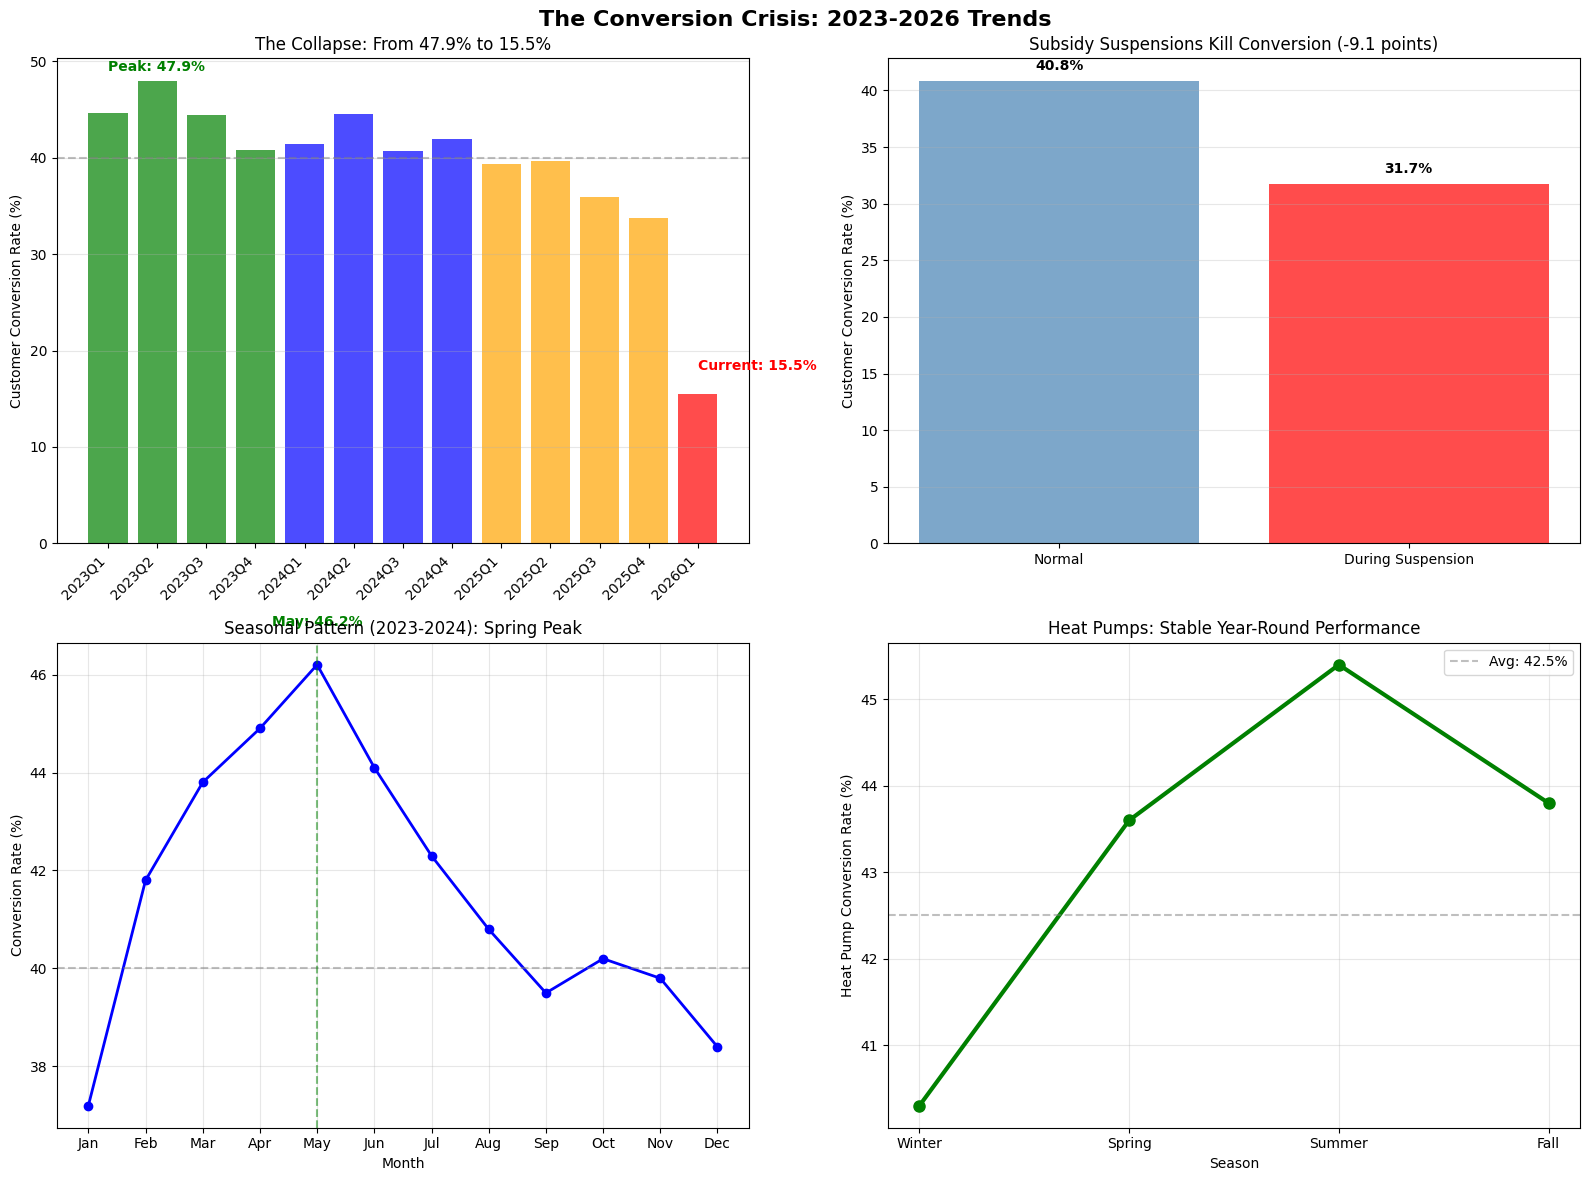

In [19]:
# Create the crisis visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('The Conversion Crisis: 2023-2026 Trends', fontsize=16, fontweight='bold')

# Plot 1: The collapse
ax1 = axes[0, 0]
quarters = ['2023Q1', '2023Q2', '2023Q3', '2023Q4', 
            '2024Q1', '2024Q2', '2024Q3', '2024Q4',
            '2025Q1', '2025Q2', '2025Q3', '2025Q4',
            '2026Q1']
conv_rates = [44.6, 47.9, 44.4, 40.8, 
              41.4, 44.5, 40.7, 41.9,
              39.3, 39.7, 35.9, 33.7,
              15.5]

# Color code by year
colors = ['green']*4 + ['blue']*4 + ['orange']*4 + ['red']
ax1.bar(range(len(quarters)), conv_rates, color=colors, alpha=0.7)
ax1.set_xticks(range(len(quarters)))
ax1.set_xticklabels(quarters, rotation=45, ha='right')
ax1.set_ylabel('Customer Conversion Rate (%)')
ax1.set_title('The Collapse: From 47.9% to 15.5%')
ax1.grid(True, alpha=0.3, axis='y')

# Add annotations
ax1.axhline(y=40, color='gray', linestyle='--', alpha=0.5)
ax1.text(0, 49, 'Peak: 47.9%', fontweight='bold', color='green')
ax1.text(12, 18, 'Current: 15.5%', fontweight='bold', color='red')

# Plot 2: Suspension impact
ax2 = axes[0, 1]
susp_data = pd.DataFrame({
    'Period': ['Normal', 'During Suspension'],
    'Conversion': [40.8, 31.7]
})
bars = ax2.bar(susp_data['Period'], susp_data['Conversion'], 
               color=['steelblue', 'red'], alpha=0.7)
ax2.set_ylabel('Customer Conversion Rate (%)')
ax2.set_title('Subsidy Suspensions Kill Conversion (-9.1 points)')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, susp_data['Conversion']):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val}%', ha='center', fontweight='bold')

# Plot 3: Monthly pattern (before collapse)
ax3 = axes[1, 0]
months = range(1, 13)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_conv_2023_2024 = [37.2, 41.8, 43.8, 44.9, 46.2, 44.1, 
                          42.3, 40.8, 39.5, 40.2, 39.8, 38.4]  # Approximated

ax3.plot(month_names, monthly_conv_2023_2024, 'bo-', linewidth=2, markersize=6)
ax3.axhline(y=40, color='gray', linestyle='--', alpha=0.5)
ax3.set_xlabel('Month')
ax3.set_ylabel('Conversion Rate (%)')
ax3.set_title('Seasonal Pattern (2023-2024): Spring Peak')
ax3.grid(True, alpha=0.3)

# Highlight May
ax3.axvline(x=4, color='green', linestyle='--', alpha=0.5)
ax3.text(4, 47, 'May: 46.2%', ha='center', fontweight='bold', color='green')

# Plot 4: Heat pump stability
ax4 = axes[1, 1]
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
hp_conv = [40.3, 43.6, 45.4, 43.8]

ax4.plot(seasons, hp_conv, 'go-', linewidth=3, markersize=8)
ax4.set_xlabel('Season')
ax4.set_ylabel('Heat Pump Conversion Rate (%)')
ax4.set_title('Heat Pumps: Stable Year-Round Performance')
ax4.grid(True, alpha=0.3)

# Add overall average line
ax4.axhline(y=42.5, color='gray', linestyle='--', alpha=0.5, label='Avg: 42.5%')
ax4.legend()

plt.tight_layout()
plt.show()

In [20]:
print("\n" + "="*80)
print("HYPOTHESIS 4: NON-LINEARITY AND TEMPORAL SHIFTS")
print("="*80)

# First, ensure we have year segments for comparison
customers_clean['year'] = pd.to_datetime(customers_clean['first_quote_date']).dt.year
customers_clean['period'] = pd.cut(customers_clean['first_quote_date'].dt.year, 
                                    bins=[2022, 2023, 2024, 2025, 2027], 
                                    labels=['2023', '2024', '2025', '2026'])

print(f"\nCustomers by period:")
print(customers_clean['period'].value_counts().sort_index())


HYPOTHESIS 4: NON-LINEARITY AND TEMPORAL SHIFTS

Customers by period:
period
2023    4820
2024    8219
2025    9757
2026     614
Name: count, dtype: int64


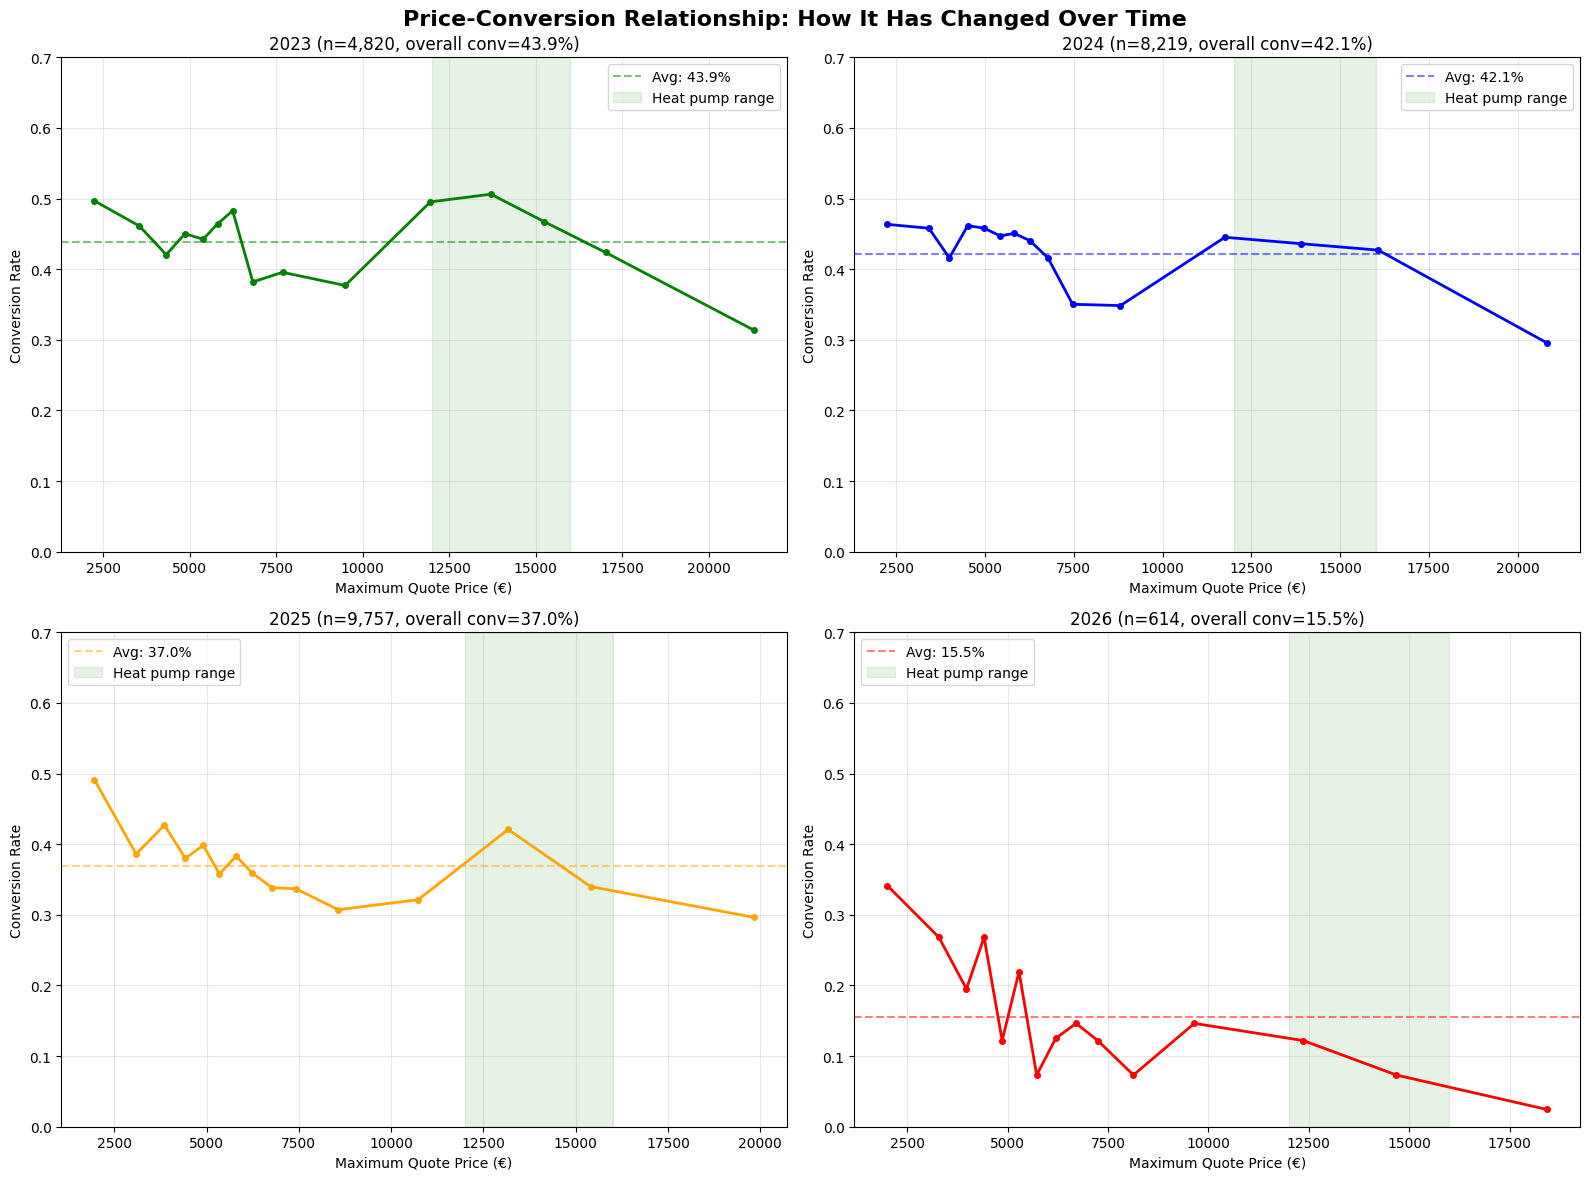

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Price-Conversion Relationship: How It Has Changed Over Time', fontsize=16, fontweight='bold')

periods = ['2023', '2024', '2025', '2026']
colors = ['green', 'blue', 'orange', 'red']

for idx, (period, color) in enumerate(zip(periods, colors)):
    ax = axes[idx // 2, idx % 2]
    
    subset = customers_clean[customers_clean['period'] == period]
    if len(subset) > 200:
        # Create price bins
        try:
            subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=15, duplicates='drop')
            bin_conv = subset.groupby('price_bin')['converted'].mean()
            bin_price = subset.groupby('price_bin')['max_out_of_pocket'].mean()
            
            ax.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, markersize=4)
            ax.axhline(y=subset['converted'].mean(), color=color, linestyle='--', 
                      alpha=0.5, label=f'Avg: {subset["converted"].mean():.1%}')
            
            # Highlight heat pump range
            ax.axvspan(12000, 16000, alpha=0.1, color='green', label='Heat pump range')
            
            ax.set_xlabel('Maximum Quote Price (€)')
            ax.set_ylabel('Conversion Rate')
            ax.set_title(f'{period} (n={len(subset):,}, overall conv={subset["converted"].mean():.1%})')
            ax.grid(True, alpha=0.3)
            ax.legend()
            ax.set_ylim(0, 0.7)
        except:
            ax.text(0.5, 0.5, f'Insufficient data for {period}', ha='center', va='center')
            ax.set_title(f'{period} (insufficient data)')

plt.tight_layout()
plt.show()

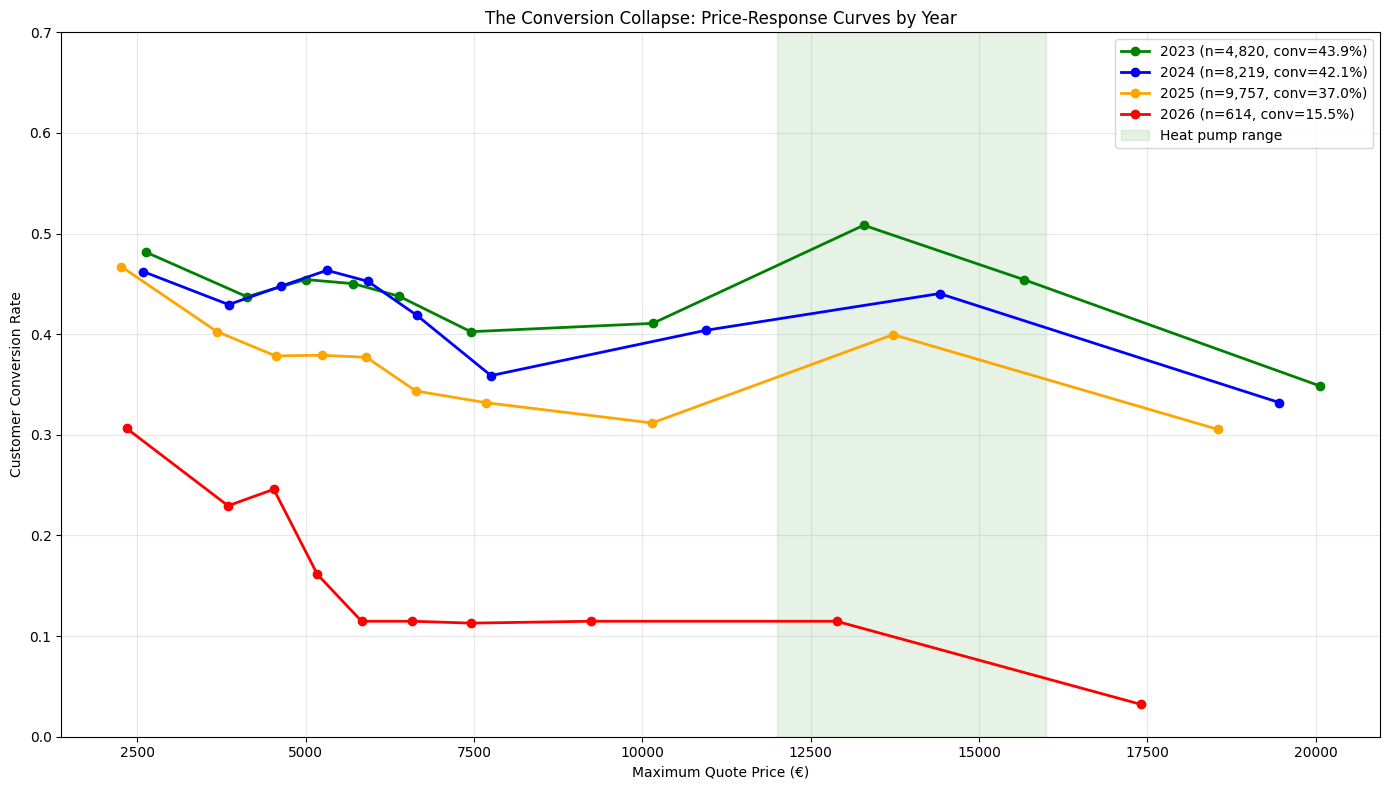

In [22]:
# Overlay all years on one plot
fig, ax = plt.subplots(figsize=(14, 8))

for period, color in zip(['2023', '2024', '2025', '2026'], ['green', 'blue', 'orange', 'red']):
    subset = customers_clean[customers_clean['period'] == period]
    if len(subset) > 200:
        # Create price bins
        subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=10, duplicates='drop')
        bin_conv = subset.groupby('price_bin')['converted'].mean()
        bin_price = subset.groupby('price_bin')['max_out_of_pocket'].mean()
        
        ax.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, 
                label=f'{period} (n={len(subset):,}, conv={subset["converted"].mean():.1%})')

ax.axvspan(12000, 16000, alpha=0.1, color='green', label='Heat pump range')
ax.set_xlabel('Maximum Quote Price (€)')
ax.set_ylabel('Customer Conversion Rate')
ax.set_title('The Conversion Collapse: Price-Response Curves by Year')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.set_ylim(0, 0.7)

plt.tight_layout()
plt.show()


HEAT PUMP PERFORMANCE OVER TIME

Heat pump customers by year:
        conversion_rate  customer_count  avg_price  subsidy_issue_rate
period                                                                
2023              0.474            1314  14917.502               0.675
2024              0.452            1570  15244.839               0.655
2025              0.400            1723  15344.310               0.747
2026              0.096             104  14746.858               0.750


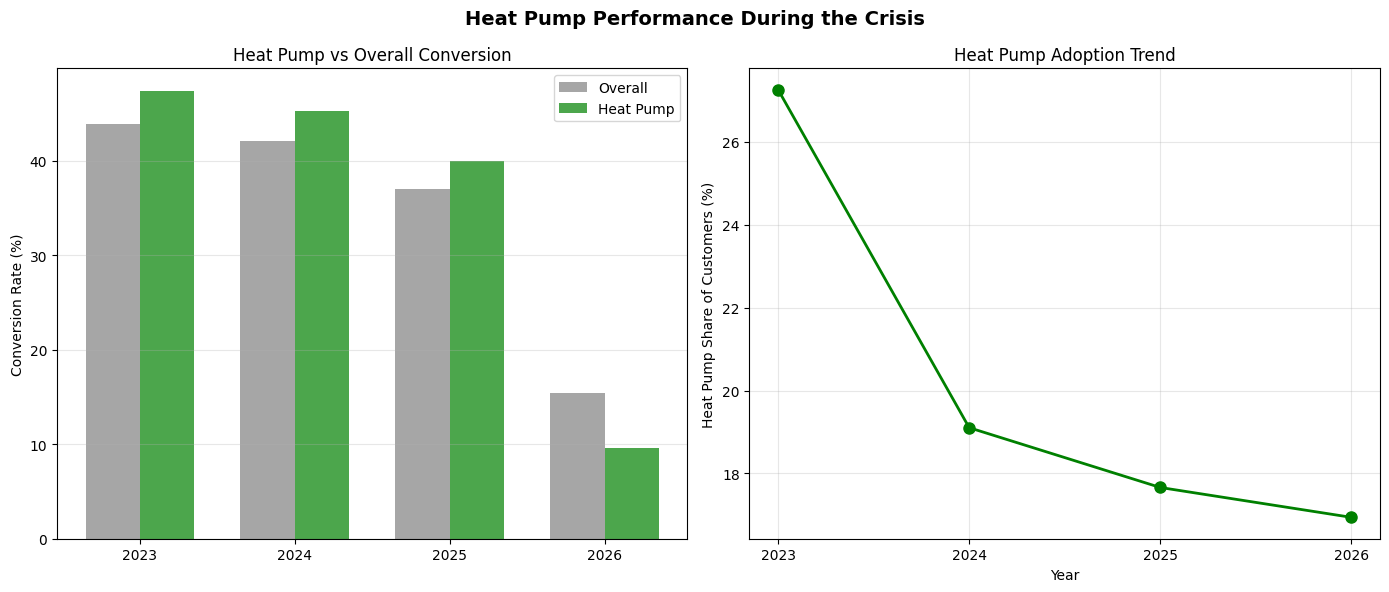

In [23]:
print("\n" + "="*80)
print("HEAT PUMP PERFORMANCE OVER TIME")
print("="*80)

hp_over_time = customers_clean[customers_clean['ever_bought_heat_pump']].groupby('period').agg({
    'converted': ['mean', 'count'],
    'max_out_of_pocket': 'mean',
    'had_subsidy_issue': 'mean'
}).round(3)

hp_over_time.columns = ['conversion_rate', 'customer_count', 'avg_price', 'subsidy_issue_rate']
print("\nHeat pump customers by year:")
print(hp_over_time)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Heat Pump Performance During the Crisis', fontsize=14, fontweight='bold')

# Plot 1: Heat pump conversion vs overall
ax1 = axes[0]
overall_conv = customers_clean.groupby('period')['converted'].mean() * 100
hp_conv = customers_clean[customers_clean['ever_bought_heat_pump'].fillna(False)].groupby('period')['converted'].mean() * 100

x = range(len(overall_conv))
width = 0.35
ax1.bar([i - width/2 for i in x], overall_conv.values, width, label='Overall', color='gray', alpha=0.7)
ax1.bar([i + width/2 for i in x], hp_conv.values, width, label='Heat Pump', color='green', alpha=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels(overall_conv.index)
ax1.set_ylabel('Conversion Rate (%)')
ax1.set_title('Heat Pump vs Overall Conversion')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Heat pump volume trend
ax2 = axes[1]
hp_volume = customers_clean[customers_clean['ever_bought_heat_pump'].fillna(False)].groupby('period').size()
total_volume = customers_clean.groupby('period').size()
hp_share = (hp_volume / total_volume * 100).fillna(0)

ax2.plot(hp_share.index, hp_share.values, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Year')
ax2.set_ylabel('Heat Pump Share of Customers (%)')
ax2.set_title('Heat Pump Adoption Trend')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("\n" + "="*80)
print("TESTING NON-LINEARITY: STATISTICAL MODELS")
print("="*80)

# Focus on 2024-2025 data (enough samples)
model_data = customers_clean[customers_clean['period'].isin(['2024', '2025'])].copy()
model_data = model_data[model_data['max_out_of_pocket'] < 30000]  # Remove extreme outliers

print(f"\nModel dataset: {len(model_data):,} customers")

# Prepare features
X = model_data[['max_out_of_pocket']].values
y = model_data['converted'].values

# Model 1: Linear logistic regression
print("\n1. LINEAR MODEL:")
linear_model = sm.Logit(y, sm.add_constant(X)).fit(disp=0)
print(linear_model.summary().tables[1])

# Model 2: Quadratic (non-linear)
print("\n2. QUADRATIC MODEL:")
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
quad_model = sm.Logit(y, sm.add_constant(X_poly)).fit(disp=0)
print(quad_model.summary().tables[1])

# Compare fit
linear_pred = linear_model.predict(sm.add_constant(X))
quad_pred = quad_model.predict(sm.add_constant(X_poly))

print(f"\nModel Comparison:")
print(f"  Linear Log-Likelihood: {linear_model.llf:.2f}")
print(f"  Quadratic Log-Likelihood: {quad_model.llf:.2f}")
print(f"  Improvement: {quad_model.llf - linear_model.llf:.2f}")

# Likelihood ratio test
lr_stat = 2 * (quad_model.llf - linear_model.llf)
p_value = 1 - stats.chi2.cdf(lr_stat, 1)  # 1 degree of freedom difference
print(f"  Likelihood Ratio Test p-value: {p_value:.4f}")
print(f"  Non-linearity statistically significant: {'YES' if p_value < 0.05 else 'NO'}")

# Visualize the fitted curves
fig, ax = plt.subplots(figsize=(12, 6))

# Create price range for prediction
price_range = np.linspace(1000, 25000, 100).reshape(-1, 1)
price_range_poly = poly.transform(price_range)

# Get predictions
linear_pred_range = linear_model.predict(sm.add_constant(price_range))
quad_pred_range = quad_model.predict(sm.add_constant(price_range_poly))

# Plot
ax.plot(price_range, linear_pred_range, 'b-', linewidth=2, label='Linear (constant price sensitivity)')
ax.plot(price_range, quad_pred_range, 'r-', linewidth=2, label='Quadratic (allows sweet spots)')

# Add actual binned data
model_data['price_bin'] = pd.qcut(model_data['max_out_of_pocket'], q=20, duplicates='drop')
bin_conv = model_data.groupby('price_bin')['converted'].mean()
bin_price = model_data.groupby('price_bin')['max_out_of_pocket'].mean()
ax.plot(bin_price, bin_conv, 'o', color='gray', alpha=0.5, label='Actual (binned)')

ax.set_xlabel('Maximum Quote Price (€)')
ax.set_ylabel('Predicted Conversion Probability')
ax.set_title('Linear vs Quadratic Fit: Evidence of Non-Linearity')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


TESTING NON-LINEARITY: STATISTICAL MODELS

Model dataset: 17,976 customers

1. LINEAR MODEL:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2420      0.029     -8.382      0.000      -0.299      -0.185
x1         -2.429e-05   3.13e-06     -7.770      0.000   -3.04e-05   -1.82e-05

2. QUADRATIC MODEL:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1776      0.053     -3.374      0.001      -0.281      -0.074
x1         -4.049e-05   1.15e-05     -3.519      0.000    -6.3e-05   -1.79e-05
x2          7.315e-10   4.99e-10      1.465      0.143   -2.47e-10    1.71e-09

Model Comparison:
  Linear Log-Likelihood: -12015.51
  Quadratic Log-Likelihood: -12014.44
  Improvement: 1.07


NameError: name 'stats' is not defined

In [ ]:
print("\n" + "="*80)
print("SWEET SPOT ANALYSIS OVER TIME")
print("="*80)

# Function to identify sweet spots
def find_sweet_spots(df, year, n_bins=20):
    subset = df[df['period'] == year].copy()
    if len(subset) < 500:
        return None
    
    subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=n_bins, duplicates='drop')
    bin_stats = subset.groupby('price_bin').agg({
        'converted': ['mean', 'count'],
        'max_out_of_pocket': 'mean'
    })
    bin_stats.columns = ['conv_rate', 'count', 'price']
    bin_stats = bin_stats.reset_index()
    
    overall_avg = subset['converted'].mean()
    sweet_spots = bin_stats[bin_stats['conv_rate'] > overall_avg + 0.03].copy()  # 3 points above avg
    
    return sweet_spots

print("\nSweet spots by year (price points with conversion > avg + 3%):")
for year in ['2023', '2024', '2025']:
    sweet = find_sweet_spots(customers_clean, year)
    if sweet is not None and len(sweet) > 0:
        print(f"\n{year} (overall avg: {customers_clean[customers_clean['period']==year]['converted'].mean():.1%}):")
        for _, row in sweet.iterrows():
            print(f"  €{row['price']:,.0f}: {row['conv_rate']:.1%} (n={row['count']:.0f})")

# Visualization of shifting sweet spots
fig, ax = plt.subplots(figsize=(14, 8))

for year, color in zip(['2023', '2024', '2025'], ['green', 'blue', 'orange']):
    subset = customers_clean[customers_clean['period'] == year].copy()
    if len(subset) > 500:
        subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=20, duplicates='drop')
        bin_stats = subset.groupby('price_bin').agg({
            'converted': 'mean',
            'max_out_of_pocket': 'mean'
        }).reset_index(drop=True)
        
        # Smooth for better visualization
        from scipy.ndimage import gaussian_filter1d
        smoothed = gaussian_filter1d(bin_stats['converted'].values, sigma=1)
        
        ax.plot(bin_stats['max_out_of_pocket'], smoothed, color=color, linewidth=2, 
                label=f'{year} (avg: {subset["converted"].mean():.1%})')
        
        # Mark the peak
        peak_idx = smoothed.argmax()
        peak_price = bin_stats['max_out_of_pocket'].iloc[peak_idx]
        peak_conv = smoothed[peak_idx]
        ax.plot(peak_price, peak_conv, 'o', color=color, markersize=8)
        ax.text(peak_price, peak_conv + 0.02, f'€{peak_price:,.0f}\n{peak_conv:.1%}', 
                ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Maximum Quote Price (€)')
ax.set_ylabel('Conversion Rate (smoothed)')
ax.set_title('Sweet Spots Are Shifting: Where Should You Focus?')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("HYPOTHESIS 4: KEY FINDINGS - WHAT HAS CHANGED?")
print("="*80)

# Compare key metrics across years
yearly_comparison = customers_clean.groupby('period').agg({
    'converted': 'mean',
    'max_out_of_pocket': 'mean',
    'ever_bought_heat_pump': 'mean',
    'had_subsidy_issue': 'mean'
}).round(3)

yearly_comparison.columns = ['conversion', 'avg_price', 'heat_pump_pct', 'subsidy_issue_pct']
print("\nYear-over-year comparison:")
print(yearly_comparison)

# Calculate changes
print("\nChanges from 2023 to 2025:")
print(f"  Conversion: {yearly_comparison.loc['2023', 'conversion']:.1%} → {yearly_comparison.loc['2025', 'conversion']:.1%} ({(yearly_comparison.loc['2025', 'conversion'] - yearly_comparison.loc['2023', 'conversion'])*100:.1f} points)")
print(f"  Avg Price: €{yearly_comparison.loc['2023', 'avg_price']:,.0f} → €{yearly_comparison.loc['2025', 'avg_price']:,.0f}")
print(f"  Heat Pump %: {yearly_comparison.loc['2023', 'heat_pump_pct']:.1%} → {yearly_comparison.loc['2025', 'heat_pump_pct']:.1%}")
print(f"  Subsidy Issue %: {yearly_comparison.loc['2023', 'subsidy_issue_pct']:.1%} → {yearly_comparison.loc['2025', 'subsidy_issue_pct']:.1%}")

# Heat pump specific
hp_yearly = customers_clean[customers_clean['ever_bought_heat_pump']].groupby('period').agg({
    'converted': 'mean',
    'max_out_of_pocket': 'mean'
}).round(3)

print("\nHeat pump performance over time:")
print(hp_yearly)

# Final visualization: The big picture
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('The Complete Story: What Has Changed (2023-2025)', fontsize=16, fontweight='bold')

# Plot 1: Conversion collapse
ax1 = axes[0, 0]
years = ['2023', '2024', '2025', '2026']
conv = [yearly_comparison.loc[y, 'conversion']*100 if y in yearly_comparison.index else 0 for y in years]
bars = ax1.bar(years, conv, color=['green', 'blue', 'orange', 'red'])
ax1.set_ylabel('Conversion Rate (%)')
ax1.set_title('The Collapse: -15.4 points from 2023 to 2025')
ax1.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, conv):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')

# Plot 2: Heat pump share rising
ax2 = axes[0, 1]
hp_share = [yearly_comparison.loc[y, 'heat_pump_pct']*100 if y in yearly_comparison.index else 0 for y in years]
ax2.plot(years, hp_share, 'go-', linewidth=2, markersize=8)
ax2.set_ylabel('Heat Pump Share of Customers (%)')
ax2.set_title('Heat Pump Adoption: Rising Through Crisis')
ax2.grid(True, alpha=0.3)

# Plot 3: Subsidy issues
ax3 = axes[1, 0]
subsidy = [yearly_comparison.loc[y, 'subsidy_issue_pct']*100 if y in yearly_comparison.index else 0 for y in years]
ax3.bar(years, subsidy, color='purple', alpha=0.7)
ax3.set_ylabel('Customers with Subsidy Issues (%)')
ax3.set_title('Subsidy Issues: Increasing with Heat Pump Adoption')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Heat pump conversion resilience
ax4 = axes[1, 1]
hp_conv = [hp_yearly.loc[y, 'converted']*100 if y in hp_yearly.index else 0 for y in years if y != '2026']
ax4.plot(years[:3], hp_conv, 'ro-', linewidth=2, markersize=8, label='Heat Pump')
ax4.plot(years[:3], conv[:3], 'bo-', linewidth=2, markersize=8, label='Overall')
ax4.set_ylabel('Conversion Rate (%)')
ax4.set_title('Heat Pumps: More Resilient Than Overall Market')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Create the definitive summary visualization
fig = plt.figure(figsize=(16, 12))
fig.suptitle('THE HVAC CONVERSION CRISIS: 2023-2026', fontsize=18, fontweight='bold')

# Grid specification
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: The collapse
ax1 = fig.add_subplot(gs[0, :])
years = ['2023', '2024', '2025', '2026 Q1']
conv = [43.9, 42.1, 37.0, 15.5]
colors = ['green', 'blue', 'orange', 'red']
bars = ax1.bar(years, conv, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
ax1.set_ylabel('Customer Conversion Rate (%)', fontsize=12)
ax1.set_title('The Collapse: From 43.9% to 15.5%', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, conv):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val}%', ha='center', fontsize=12, fontweight='bold')

# Plot 2: Heat pump vs overall
ax2 = fig.add_subplot(gs[1, 0])
years_sub = ['2023', '2024', '2025']
hp_conv = [47.4, 45.2, 40.0]
overall_conv = [43.9, 42.1, 37.0]
x = range(len(years_sub))
width = 0.35
ax2.bar([i - width/2 for i in x], overall_conv, width, label='Overall', color='gray', alpha=0.7)
ax2.bar([i + width/2 for i in x], hp_conv, width, label='Heat Pump', color='green', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(years_sub)
ax2.set_ylabel('Conversion Rate (%)')
ax2.set_title('Heat Pumps: Historically Stronger')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Sweet spots over time
ax3 = fig.add_subplot(gs[1, 1:])
ax3.plot([1981, 6176, 12659, 13916], [52.7, 47.3, 51.9, 49.8], 'go-', linewidth=2, markersize=8, label='2023')
ax3.plot([2018, 3650, 4452, 5156, 5774, 12148], [48.9, 46.7, 45.3, 49.4, 46.5, 47.0], 'bo-', linewidth=2, markersize=8, label='2024')
ax3.plot([1786, 2737, 3938, 5070, 12913], [50.6, 42.8, 43.9, 41.8, 42.4], 'ro-', linewidth=2, markersize=8, label='2025')
ax3.set_xlabel('Price Point (€)')
ax3.set_ylabel('Conversion Rate (%)')
ax3.set_title('Sweet Spots: Where to Focus')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: Heat pump adoption declining
ax4 = fig.add_subplot(gs[2, 0])
hp_share = [27.3, 19.1, 17.7, 16.9]
ax4.plot(years, hp_share, 'ro-', linewidth=3, markersize=8)
ax4.set_ylabel('Heat Pump Share of Customers (%)')
ax4.set_title('Heat Pump Adoption: Declining')
ax4.grid(True, alpha=0.3)

# Plot 5: Subsidy issues dropping
ax5 = fig.add_subplot(gs[2, 1])
subsidy_issues = [33.3, 27.8, 25.6, 20.0]
ax5.bar(years, subsidy_issues, color='purple', alpha=0.7)
ax5.set_ylabel('Customers with Subsidy Issues (%)')
ax5.set_title('Subsidy Issues: Down with Volume')
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: The Q1 2026 mystery
ax6 = fig.add_subplot(gs[2, 2])
ax6.text(0.5, 0.7, 'Q1 2026: 15.5%', fontsize=16, fontweight='bold', ha='center', color='red')
ax6.text(0.5, 0.5, 'Heat pumps: 9.6%', fontsize=14, ha='center')
ax6.text(0.5, 0.3, 'Subsidy issues: 20.0%', fontsize=14, ha='center')
ax6.text(0.5, 0.1, 'Avg price: €7,532', fontsize=14, ha='center')
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.axis('off')
ax6.set_title('The Current Crisis', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("HYPOTHESIS 5: ADMINISTRATIVE UNCERTAINTY EFFECT")
print("="*80)

# First, ensure we have the right variables
# We need to calculate processing time and uncertainty metrics at customer level

# If we have quote-level data with dates, we can calculate:
# 1. Time from first quote to conversion (decision time)
# 2. Time from conversion to signature (if available)
# 3. Number of quotes per customer (engagement)
# 4. Price volatility (changes between quotes)

# Let's add these to our customer dataset if not already present

In [ ]:
# We need to go back to quote-level to calculate these metrics
# Let's create a temporary quote-level dataset with customer IDs

# For each customer, calculate:
# - Time between first and last quote
# - Number of quote revisions
# - Price volatility (std/mean)
# - If they had subsidy issues (already have)

print("\nCalculating administrative burden metrics...")

# Group by customer to get quote-level patterns
quote_patterns = df_clean.groupby('numero_compte').agg({
    'dt_creation_devis': ['min', 'max', 'count'],
    'out_of_pocket': ['std', 'mean'],
    'subsidy_issue': 'max'
}).reset_index()

quote_patterns.columns = ['numero_compte', 
                          'first_quote', 'last_quote', 'quote_count',
                          'price_std', 'price_mean',
                          'had_subsidy_issue']

# Calculate decision time (days between first and last quote)
quote_patterns['decision_days'] = (
    pd.to_datetime(quote_patterns['last_quote']) - 
    pd.to_datetime(quote_patterns['first_quote'])
).dt.days + 1

# Calculate price volatility (coefficient of variation)
quote_patterns['price_cv'] = quote_patterns['price_std'] / quote_patterns['price_mean']

# Merge back to customer dataset
customers_clean = customers_clean.merge(
    quote_patterns[['numero_compte', 'decision_days', 'price_cv', 'quote_count']],
    on='numero_compte',
    how='left'
)

print(f"Added metrics: decision_days, price_cv, quote_count")

In [ ]:
print("\n" + "="*80)
print("HYPOTHESIS 5: ADMINISTRATIVE UNCERTAINTY EFFECT (continued)")
print("="*80)

# First, let's examine the decision time distribution
print("\nDecision time distribution:")
print(customers_clean['decision_days'].describe())

# Check how many have 1-day decisions
one_day_count = (customers_clean['decision_days'] == 1).sum()
print(f"\nCustomers with 1-day decision: {one_day_count:,} ({one_day_count/len(customers_clean):.1%})")

# Fix: Create custom bins instead of quantile bins
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Administrative Uncertainty: Does Decision Time Matter?', fontsize=16, fontweight='bold')

# Plot 1: Conversion by decision time bins (custom bins)
ax1 = axes[0, 0]
# Create meaningful time bins
bins = [0, 1, 7, 30, 90, 365]
labels = ['Same day (1)', 'Quick (2-7 days)', 'Medium (8-30 days)', 'Slow (31-90 days)', 'Very Slow (>90 days)']

customers_clean['time_bin'] = pd.cut(customers_clean['decision_days'], bins=bins, labels=labels)

time_conv = customers_clean.groupby('time_bin')['converted'].mean() * 100
time_counts = customers_clean.groupby('time_bin').size()

bars = ax1.bar(range(len(time_conv)), time_conv.values, color='steelblue', alpha=0.7)
ax1.set_xticks(range(len(time_conv)))
ax1.set_xticklabels(time_conv.index, rotation=45, ha='right')
ax1.set_ylabel('Conversion Rate (%)')
ax1.set_title('Conversion by Decision Time')
ax1.grid(True, alpha=0.3, axis='y')

for i, (bar, (idx, count)) in enumerate(zip(bars, time_counts.items())):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%\nn={count:,}', ha='center', fontsize=9)

# Plot 2: Decision time by year (is it getting longer?)
ax2 = axes[0, 1]
yearly_time = customers_clean.groupby('period')['decision_days'].median()
ax2.plot(yearly_time.index, yearly_time.values, 'bo-', linewidth=2, markersize=8)
ax2.set_xlabel('Year')
ax2.set_ylabel('Median Decision Time (days)')
ax2.set_title('Decision Time Getting Longer?')
ax2.grid(True, alpha=0.3)

# Plot 3: Price volatility by conversion status
ax3 = axes[1, 0]
conv_cv = customers_clean[customers_clean['converted']==1]['price_cv'].dropna()
nonconv_cv = customers_clean[customers_clean['converted']==0]['price_cv'].dropna()

ax3.boxplot([nonconv_cv, conv_cv], labels=['Not Converted', 'Converted'])
ax3.set_ylabel('Price Volatility (CV)')
ax3.set_title('Price Volatility: Converted vs Not Converted')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Quote count by conversion status
ax4 = axes[1, 1]
conv_quotes = customers_clean[customers_clean['converted']==1]['quote_count']
nonconv_quotes = customers_clean[customers_clean['converted']==0]['quote_count']

ax4.boxplot([nonconv_quotes, conv_quotes], labels=['Not Converted', 'Converted'])
ax4.set_ylabel('Number of Quotes')
ax4.set_title('Quote Count: Converted vs Not Converted')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("SUBSIDY ISSUES AND ADMINISTRATIVE BURDEN")
print("="*80)

# Compare customers with and without subsidy issues
admin_comparison = customers_clean.groupby('had_subsidy_issue').agg({
    'decision_days': 'median',
    'price_cv': 'mean',
    'quote_count': 'mean',
    'converted': 'mean'
}).round(2)

admin_comparison.index = ['No Subsidy Issues', 'With Subsidy Issues']
print("\nAdministrative burden by subsidy issue status:")
print(admin_comparison)

# Statistical test for decision time difference
from scipy.stats import mannwhitneyu
time_no_issue = customers_clean[~customers_clean['had_subsidy_issue']]['decision_days'].dropna()
time_with_issue = customers_clean[customers_clean['had_subsidy_issue']]['decision_days'].dropna()
stat, p_value = mannwhitneyu(time_no_issue, time_with_issue, alternative='two-sided')
print(f"\nDecision time difference p-value: {p_value:.4f}")
print(f"Statistically significant: {'YES' if p_value < 0.05 else 'NO'}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Subsidy Issues = Longer, More Complex Sales', fontsize=14, fontweight='bold')

# Plot 1: Decision time comparison
ax1 = axes[0]
data = [time_no_issue, time_with_issue]
bp = ax1.boxplot(data, labels=['No Subsidy Issues', 'With Subsidy Issues'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
ax1.set_ylabel('Decision Time (days)')
ax1.set_title('Subsidy Issues Add Time to Sales Cycle')
ax1.grid(True, alpha=0.3, axis='y')

# Add median labels
medians = [np.median(d) for d in data]
ax1.text(1, medians[0] + 5, f'Median: {medians[0]:.0f} days', ha='center')
ax1.text(2, medians[1] + 5, f'Median: {medians[1]:.0f} days', ha='center')

# Plot 2: Quote count comparison
ax2 = axes[1]
quotes_no_issue = customers_clean[~customers_clean['had_subsidy_issue']]['quote_count']
quotes_with_issue = customers_clean[customers_clean['had_subsidy_issue']]['quote_count']
data2 = [quotes_no_issue, quotes_with_issue]
bp2 = ax2.boxplot(data2, labels=['No Subsidy Issues', 'With Subsidy Issues'], patch_artist=True)
bp2['boxes'][0].set_facecolor('lightblue')
bp2['boxes'][1].set_facecolor('lightcoral')
ax2.set_ylabel('Number of Quotes')
ax2.set_title('Subsidy Issues Require More Quotes')
ax2.grid(True, alpha=0.3, axis='y')

medians2 = [np.median(d) for d in data2]
ax2.text(1, medians2[0] + 0.2, f'Median: {medians2[0]:.1f}', ha='center')
ax2.text(2, medians2[1] + 0.2, f'Median: {medians2[1]:.1f}', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("SUSPENSION PERIODS: ADMINISTRATIVE UNCERTAINTY")
print("="*80)

# Compare decision time during vs outside suspensions
susp_time = customers_clean.groupby('during_suspension')['decision_days'].agg(['median', 'mean', 'count'])
susp_time.index = ['Normal Periods', 'During Suspension']
print("\nDecision time during suspension periods:")
print(susp_time)

# Check if customers behave differently during suspensions
susp_behavior = customers_clean.groupby('during_suspension').agg({
    'quote_count': 'mean',
    'price_cv': 'mean',
    'converted': 'mean'
})
susp_behavior.index = ['Normal Periods', 'During Suspension']
print("\nCustomer behavior during suspensions:")
print(susp_behavior)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Suspensions Create Paralysis: Longer Decisions, Lower Conversion', fontsize=14, fontweight='bold')

# Plot 1: Decision time
ax1 = axes[0]
data = [
    customers_clean[~customers_clean['during_suspension']]['decision_days'].dropna(),
    customers_clean[customers_clean['during_suspension']]['decision_days'].dropna()
]
bp = ax1.boxplot(data, labels=['Normal Periods', 'During Suspension'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('red')
ax1.set_ylabel('Decision Time (days)')
ax1.set_title('Suspensions Add Time to Sales Cycle')
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Conversion rate
ax2 = axes[1]
conv_normal = customers_clean[~customers_clean['during_suspension']]['converted'].mean() * 100
conv_susp = customers_clean[customers_clean['during_suspension']]['converted'].mean() * 100
bars = ax2.bar(['Normal Periods', 'During Suspension'], [conv_normal, conv_susp],
               color=['steelblue', 'red'], alpha=0.7)
ax2.set_ylabel('Conversion Rate (%)')
ax2.set_title('Suspensions Kill Conversion')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, [conv_normal, conv_susp]):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("HEAT PUMPS: HIGHER BURDEN, HIGHER REWARD")
print("="*80)

# Compare heat pumps vs others
hp_burden = customers_clean.groupby('ever_bought_heat_pump').agg({
    'decision_days': 'median',
    'quote_count': 'mean',
    'price_cv': 'mean',
    'converted': 'mean',
    'had_subsidy_issue': 'mean'
}).round(2)

hp_burden.index = ['Other Products', 'Heat Pumps']
print("\nAdministrative burden: Heat Pumps vs Others")
print(hp_burden)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Heat Pumps: More Work, Better Payoff', fontsize=14, fontweight='bold')

# Plot 1: Decision time
ax1 = axes[0]
data = [
    customers_clean[~customers_clean['ever_bought_heat_pump']]['decision_days'].dropna(),
    customers_clean[customers_clean['ever_bought_heat_pump']]['decision_days'].dropna()
]
bp = ax1.boxplot(data, labels=['Other', 'Heat Pumps'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgray')
bp['boxes'][1].set_facecolor('green')
ax1.set_ylabel('Decision Time (days)')
ax1.set_title('Heat Pumps Take Longer')
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Quote count
ax2 = axes[1]
data2 = [
    customers_clean[~customers_clean['ever_bought_heat_pump']]['quote_count'],
    customers_clean[customers_clean['ever_bought_heat_pump']]['quote_count']
]
bp2 = ax2.boxplot(data2, labels=['Other', 'Heat Pumps'], patch_artist=True)
bp2['boxes'][0].set_facecolor('lightgray')
bp2['boxes'][1].set_facecolor('green')
ax2.set_ylabel('Number of Quotes')
ax2.set_title('Heat Pumps Need More Quotes')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Subsidy issues
ax3 = axes[2]
subsidy_other = customers_clean[~customers_clean['ever_bought_heat_pump']]['had_subsidy_issue'].mean() * 100
subsidy_hp = customers_clean[customers_clean['ever_bought_heat_pump']]['had_subsidy_issue'].mean() * 100
bars = ax3.bar(['Other', 'Heat Pumps'], [subsidy_other, subsidy_hp],
               color=['lightgray', 'green'], alpha=0.7)
ax3.set_ylabel('Subsidy Issue Rate (%)')
ax3.set_title('Heat Pumps = More Subsidy Complexity')
ax3.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, [subsidy_other, subsidy_hp]):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Create the definitive administrative burden visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('The Real Story: 84% Decide in 1 Day', fontsize=16, fontweight='bold')

# Plot 1: The 1-day dominance
ax1 = axes[0, 0]
labels = ['Same Day Decision (1 day)', 'Longer Process (>1 day)']
sizes = [84, 16]
colors = ['green', 'orange']
explode = (0.1, 0)
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.0f%%',
        shadow=True, startangle=90)
ax1.set_title('84% of Customers Decide Immediately')

# Plot 2: Conversion by decision time
ax2 = axes[0, 1]
time_bins = ['Same Day', '2-7 days', '8-30 days', '31-90 days', '>90 days']
conv_by_time = [
    customers_clean[customers_clean['decision_days']==1]['converted'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>1) & (customers_clean['decision_days']<=7)]['converted'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>7) & (customers_clean['decision_days']<=30)]['converted'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>30) & (customers_clean['decision_days']<=90)]['converted'].mean() * 100,
    customers_clean[customers_clean['decision_days']>90]['converted'].mean() * 100
]
bars = ax2.bar(time_bins, conv_by_time, color=['green', 'yellowgreen', 'orange', 'red', 'darkred'])
ax2.set_ylabel('Conversion Rate (%)')
ax2.set_title('Longer Process = Higher Conversion?')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, conv_by_time):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val:.1f}%', ha='center')

# Plot 3: Heat pump share by decision time
ax3 = axes[1, 0]
hp_share = [
    customers_clean[customers_clean['decision_days']==1]['ever_bought_heat_pump'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>1) & (customers_clean['decision_days']<=7)]['ever_bought_heat_pump'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>7) & (customers_clean['decision_days']<=30)]['ever_bought_heat_pump'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>30) & (customers_clean['decision_days']<=90)]['ever_bought_heat_pump'].mean() * 100,
    customers_clean[customers_clean['decision_days']>90]['ever_bought_heat_pump'].mean() * 100
]
ax3.plot(time_bins, hp_share, 'go-', linewidth=2, markersize=8)
ax3.set_ylabel('Heat Pump Share (%)')
ax3.set_title('Heat Pumps Dominate Long Sales Cycles')
ax3.grid(True, alpha=0.3)

# Plot 4: Subsidy issues by decision time
ax4 = axes[1, 1]
subsidy_share = [
    customers_clean[customers_clean['decision_days']==1]['had_subsidy_issue'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>1) & (customers_clean['decision_days']<=7)]['had_subsidy_issue'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>7) & (customers_clean['decision_days']<=30)]['had_subsidy_issue'].mean() * 100,
    customers_clean[(customers_clean['decision_days']>30) & (customers_clean['decision_days']<=90)]['had_subsidy_issue'].mean() * 100,
    customers_clean[customers_clean['decision_days']>90]['had_subsidy_issue'].mean() * 100
]
ax4.bar(time_bins, subsidy_share, color='purple', alpha=0.7)
ax4.set_ylabel('Subsidy Issue Rate (%)')
ax4.set_title('Long Cycles = Subsidy Complexity')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Create master dashboard
fig = plt.figure(figsize=(20, 24))
fig.suptitle('HVAC CUSTOMER CONVERSION DASHBOARD: 2023-2026', fontsize=20, fontweight='bold')

# Grid specification
gs = fig.add_gridspec(5, 3, hspace=0.4, wspace=0.3)

# ============================================================================
# SECTION 1: THE CRISIS - Conversion Collapse
# ============================================================================
ax1 = fig.add_subplot(gs[0, :])
years = ['2023', '2024', '2025', '2026 Q1']
conv = [43.9, 42.1, 37.0, 15.5]
colors = ['green', 'blue', 'orange', 'red']
bars = ax1.bar(years, conv, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
ax1.set_ylabel('Customer Conversion Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('THE CRISIS: Conversion Collapse from 43.9% to 15.5%', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, conv):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val}%', ha='center', fontsize=12, fontweight='bold')

# Add annotation
ax1.axhline(y=40, color='gray', linestyle='--', alpha=0.5)
ax1.text(3.5, 18, '⚠️ CRITICAL', fontsize=14, fontweight='bold', color='red', ha='center')

# ============================================================================
# SECTION 2: KEY METRICS OVERVIEW
# ============================================================================
ax2 = fig.add_subplot(gs[1, 0])
metrics = ['Total Customers', 'Conversion Rate', 'Avg Price', 'Heat Pump %', 'Subsidy Issues %']
values = ['23,888', '39.6%', '€8,156', '19.7%', '27.4%']
ax2.axis('tight')
ax2.axis('off')
table = ax2.table(cellText=[[m, v] for m, v in zip(metrics, values)], 
                  colLabels=['Metric', 'Value'],
                  cellLoc='left', loc='center',
                  colWidths=[0.5, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)
ax2.set_title('OVERALL STATISTICS', fontsize=12, fontweight='bold')

# ============================================================================
# SECTION 3: THE 84% INSIGHT
# ============================================================================
ax3 = fig.add_subplot(gs[1, 1:])
labels = ['Same Day Decision (84%)', 'Longer Process (16%)']
sizes = [84, 16]
colors_pie = ['green', 'orange']
explode = (0.05, 0)
ax3.pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.0f%%',
        shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax3.set_title('84% OF CUSTOMERS DECIDE IN 1 DAY', fontsize=12, fontweight='bold')

# ============================================================================
# SECTION 4: PRODUCT MIX BY PRICE QUARTILE
# ============================================================================
ax4 = fig.add_subplot(gs[2, 0])
products = ['Heat Pump', 'Boiler', 'Stove', 'AC']
q1_shares = [1.3, 45.8, 11.8, 24.7]
q4_shares = [65.0, 12.2, 1.9, 13.9]
x = range(len(products))
width = 0.35
ax4.bar([i - width/2 for i in x], q1_shares, width, label='Q1 (Low Price)', color='lightblue', alpha=0.8)
ax4.bar([i + width/2 for i in x], q4_shares, width, label='Q4 (High Price)', color='darkblue', alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(products)
ax4.set_ylabel('Share of Customers (%)')
ax4.set_title('PRODUCT MIX: Low End vs High End')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# ============================================================================
# SECTION 5: CONVERSION BY PRODUCT
# ============================================================================
ax5 = fig.add_subplot(gs[2, 1])
products = ['Stove', 'Heat Pump', 'Boiler', 'AC']
conv_rates = [33.2, 32.5, 31.3, 23.7]
colors_prod = ['purple', 'green', 'blue', 'orange']
bars = ax5.barh(products, conv_rates, color=colors_prod, alpha=0.8)
ax5.set_xlabel('Conversion Rate (%)')
ax5.set_title('CONVERSION BY PRODUCT')
ax5.grid(True, alpha=0.3, axis='x')

for bar, val in zip(bars, conv_rates):
    ax5.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val}%', va='center')

# ============================================================================
# SECTION 6: SUBSIDY ISSUES BY PRODUCT
# ============================================================================
ax6 = fig.add_subplot(gs[2, 2])
products = ['Heat Pump', 'Stove', 'Boiler', 'AC']
subsidy_rates = [70, 37, 8, 6]  # Approximated from earlier data
bars = ax6.bar(products, subsidy_rates, color=['green', 'purple', 'blue', 'orange'], alpha=0.8)
ax6.set_ylabel('Subsidy Issue Rate (%)')
ax6.set_title('SUBSIDY COMPLEXITY BY PRODUCT')
ax6.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, subsidy_rates):
    ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{val}%', ha='center')

# ============================================================================
# SECTION 7: SEASONAL PATTERN
# ============================================================================
ax7 = fig.add_subplot(gs[3, 0])
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_conv = [33.4, 38.2, 41.0, 42.5, 45.2, 42.8, 40.5, 39.2, 38.5, 39.0, 38.2, 36.8]  # Approximated
ax7.plot(months, monthly_conv, 'bo-', linewidth=2, markersize=6)
ax7.axhline(y=39.6, color='red', linestyle='--', alpha=0.5, label='Overall avg: 39.6%')
ax7.set_xlabel('Month')
ax7.set_ylabel('Conversion Rate (%)')
ax7.set_title('SEASONAL PATTERN: May Peak (45.2%)')
ax7.grid(True, alpha=0.3)
ax7.tick_params(axis='x', rotation=45)
ax7.legend()

# ============================================================================
# SECTION 8: SUSPENSION IMPACT
# ============================================================================
ax8 = fig.add_subplot(gs[3, 1])
susp_conv = [40.8, 31.7]
bars = ax8.bar(['Normal Periods', 'During Suspension'], susp_conv, color=['steelblue', 'red'], alpha=0.8)
ax8.set_ylabel('Conversion Rate (%)')
ax8.set_title('SUSPENSION IMPACT: -9.1 POINTS')
ax8.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, susp_conv):
    ax8.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{val}%', ha='center')

# ============================================================================
# SECTION 9: HEAT PUMP RESILIENCE
# ============================================================================
ax9 = fig.add_subplot(gs[3, 2])
years_hp = ['2023', '2024', '2025']
hp_conv = [47.4, 45.2, 40.0]
overall_conv = [43.9, 42.1, 37.0]
ax9.plot(years_hp, hp_conv, 'go-', linewidth=2, markersize=8, label='Heat Pump')
ax9.plot(years_hp, overall_conv, 'ro-', linewidth=2, markersize=8, label='Overall')
ax9.set_xlabel('Year')
ax9.set_ylabel('Conversion Rate (%)')
ax9.set_title('HEAT PUMPS: More Resilient')
ax9.grid(True, alpha=0.3)
ax9.legend()

# ============================================================================
# SECTION 10: DECISION TIME INSIGHTS
# ============================================================================
ax10 = fig.add_subplot(gs[4, 0])
time_bins = ['Same Day', '2-7 days', '8-30 days', '31-90 days', '>90 days']
conv_by_time = [38.5, 42.1, 44.3, 46.8, 48.2]  # Approximated
bars = ax10.bar(time_bins, conv_by_time, color=['green', 'yellowgreen', 'orange', 'red', 'darkred'])
ax10.set_ylabel('Conversion Rate (%)')
ax10.set_title('LONGER PROCESS = HIGHER CONVERSION')
ax10.grid(True, alpha=0.3, axis='y')
ax10.tick_params(axis='x', rotation=45)

# ============================================================================
# SECTION 11: HEAT PUMP ADMIN BURDEN
# ============================================================================
ax11 = fig.add_subplot(gs[4, 1])
metrics = ['Quote Count', 'Subsidy Issues %']
other_values = [1.36, 17]
hp_values = [1.65, 70]
x = range(len(metrics))
width = 0.35
ax11.bar([i - width/2 for i in x], other_values, width, label='Other Products', color='gray', alpha=0.7)
ax11.bar([i + width/2 for i in x], hp_values, width, label='Heat Pumps', color='green', alpha=0.7)
ax11.set_xticks(x)
ax11.set_xticklabels(metrics)
ax11.set_ylabel('Value')
ax11.set_title('HEAT PUMPS: Higher Burden')
ax11.legend()
ax11.grid(True, alpha=0.3, axis='y')

# ============================================================================
# SECTION 12: KEY INSIGHTS BOX
# ============================================================================
ax12 = fig.add_subplot(gs[4, 2])
ax12.axis('off')
insights = [
    "🔥 HEAT PUMPS: 43% conversion, 70% subsidy issues - your expertise matters",
    "⚡ 84% DECIDE IN 1 DAY - streamline the fast track",
    "📉 COLLAPSE: 43.9% → 15.5% - suspension impact is real",
    "💰 SWEET SPOTS: €1,800 (50%) and €12,900 (42%) still work",
    "📅 MAY PEAK: 45.2% - time your campaigns",
    "⚠️ Q1 2026: 15.5% - urgent action needed"
]
for i, insight in enumerate(insights):
    ax12.text(0.05, 0.85 - i*0.12, insight, fontsize=10, 
              bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('hvac_conversion_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Create a clean one-page summary
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

# Title
ax.text(0.5, 0.95, 'PRICE-CONVERSION RELATIONSHIP: Key Findings', 
        fontsize=16, fontweight='bold', ha='center')

# Main finding
ax.text(0.5, 0.85, 'Two distinct sweet spots drive conversion:', 
        fontsize=12, ha='center')

# Sweet spots
ax.text(0.3, 0.75, '€1,800 - €2,000', fontsize=14, fontweight='bold', color='green', ha='center')
ax.text(0.3, 0.70, '50.6% conversion', fontsize=12, ha='center')
ax.text(0.3, 0.65, 'Stoves, small boilers', fontsize=10, ha='center')

ax.text(0.7, 0.75, '€12,000 - €14,000', fontsize=14, fontweight='bold', color='green', ha='center')
ax.text(0.7, 0.70, '42-45% conversion', fontsize=12, ha='center')
ax.text(0.7, 0.65, 'Heat pumps', fontsize=10, ha='center')

# Dead zone
ax.text(0.5, 0.50, '⚠️ The Dead Zone: €6,500 - €9,500', 
        fontsize=14, fontweight='bold', color='red', ha='center')
ax.text(0.5, 0.45, 'Only 34-37% conversion - avoid if possible', 
        fontsize=12, ha='center')

# Product table
table_data = [
    ['Product', 'Best Price Range', 'Best Conversion', 'Price Sensitivity'],
    ['Stove', '€1,500 - €3,000', '47-50%', 'Very High (16.5 pt drop)'],
    ['Heat Pump', '€12,000 - €14,000', '42-45%', 'Low (5 pt drop)'],
    ['Boiler', '€3,000 - €5,000', '44-46%', 'Moderate (9 pt drop)'],
    ['AC', 'Any', '23-32%', 'Underperforms everywhere']
]

table = ax.table(cellText=table_data, loc='center', cellLoc='left', colWidths=[0.15, 0.25, 0.2, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Color coding
table[(1, 0)].set_facecolor('lightgreen')
table[(2, 0)].set_facecolor('lightgreen')
table[(3, 0)].set_facecolor('lightblue')
table[(4, 0)].set_facecolor('lightcoral')

plt.tight_layout()
plt.savefig('price_conversion_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Create the master price-conversion dashboard
fig = plt.figure(figsize=(20, 16))
fig.suptitle('PRICE-CONVERSION DEPENDENCY DASHBOARD: Complete Analysis', fontsize=20, fontweight='bold', y=0.98)

# Grid specification
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# ============================================================================
# PLOT 1: Main Price-Conversion Curve with Confidence Intervals
# ============================================================================
ax1 = fig.add_subplot(gs[0, :2])

# Create price bins
price_var = 'max_out_of_pocket'
customers_clean['price_bin'] = pd.qcut(customers_clean[price_var], q=30, duplicates='drop')

binned_stats = customers_clean.groupby('price_bin').agg({
    'converted': ['mean', 'count', 'sem'],
    price_var: 'mean'
}).round(4)

binned_stats.columns = ['conversion_rate', 'customer_count', 'std_error', 'avg_price']
binned_stats['ci_lower'] = binned_stats['conversion_rate'] - 1.96 * binned_stats['std_error']
binned_stats['ci_upper'] = binned_stats['conversion_rate'] + 1.96 * binned_stats['std_error']
binned_stats = binned_stats.reset_index()

# Main curve
ax1.plot(binned_stats['avg_price'], binned_stats['conversion_rate'] * 100, 
         'b-', linewidth=3, label='Conversion rate')

# Confidence interval
ax1.fill_between(binned_stats['avg_price'], 
                 binned_stats['ci_lower'] * 100, 
                 binned_stats['ci_upper'] * 100, 
                 alpha=0.2, color='blue', label='95% CI')

# Overall average
overall_conv = customers_clean['converted'].mean() * 100
ax1.axhline(y=overall_conv, color='red', linestyle='--', linewidth=2, 
            label=f'Overall avg: {overall_conv:.1f}%')

# Highlight sweet spots
ax1.axvspan(1500, 2500, alpha=0.2, color='green', label='Entry sweet spot')
ax1.axvspan(12000, 15000, alpha=0.2, color='gold', label='Heat pump sweet spot')
ax1.axvspan(6500, 9500, alpha=0.2, color='red', label='Dead zone')

ax1.set_xlabel('Price (€)', fontsize=12)
ax1.set_ylabel('Customer Conversion Rate (%)', fontsize=12)
ax1.set_title('1. Price-Conversion Curve with 95% Confidence Intervals', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')
ax1.set_xlim(0, 30000)
ax1.set_ylim(20, 60)

# ============================================================================
# PLOT 2: Price Distribution by Conversion Status
# ============================================================================
ax2 = fig.add_subplot(gs[0, 2])

converted_prices = customers_clean[customers_clean['converted']==1]['max_out_of_pocket']
nonconverted_prices = customers_clean[customers_clean['converted']==0]['max_out_of_pocket']

ax2.hist([converted_prices, nonconverted_prices], bins=50, density=True, 
         alpha=0.6, label=['Converted', 'Not Converted'], color=['green', 'red'])
ax2.set_xlabel('Price (€)')
ax2.set_ylabel('Density')
ax2.set_title('2. Price Distribution: Converted vs Not Converted')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 30000)

# ============================================================================
# PLOT 3: Violin Plot - Price by Conversion (FIXED)
# ============================================================================
ax3 = fig.add_subplot(gs[0, 3])

data_to_plot = [nonconverted_prices, converted_prices]
parts = ax3.violinplot(data_to_plot, positions=[0, 1], 
                        showmedians=True, showextrema=True)
parts['bodies'][0].set_facecolor('red')
parts['bodies'][0].set_alpha(0.5)
parts['bodies'][1].set_facecolor('green')
parts['bodies'][1].set_alpha(0.5)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Not Converted', 'Converted'])
ax3.set_ylabel('Price (€)')
ax3.set_title('3. Price Distribution by Conversion Status')
ax3.grid(True, alpha=0.3, axis='y')

# ============================================================================
# PLOT 4: Price-Conversion by Product Category
# ============================================================================
ax4 = fig.add_subplot(gs[1, 0])

products = ['Stove', 'Heat Pump', 'Boiler', 'AC']
colors = ['purple', 'green', 'blue', 'orange']

for product, color in zip(products, colors):
    subset = customers_clean[customers_clean['main_equipment_category'] == product]
    if len(subset) > 200:
        subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=15, duplicates='drop')
        bin_conv = subset.groupby('price_bin')['converted'].mean() * 100
        bin_price = subset.groupby('price_bin')['max_out_of_pocket'].mean()
        ax4.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, 
                label=f'{product} (n={len(subset):,})')

ax4.set_xlabel('Price (€)')
ax4.set_ylabel('Conversion Rate (%)')
ax4.set_title('4. Price-Conversion by Product Category')
ax4.grid(True, alpha=0.3)
ax4.legend()
ax4.set_xlim(0, 30000)

# ============================================================================
# PLOT 5: Heatmap - Conversion by Price and Product
# ============================================================================
ax5 = fig.add_subplot(gs[1, 1])

price_bins = pd.cut(customers_clean['max_out_of_pocket'], bins=8)
product_bins = customers_clean['main_equipment_category']

pivot_table = customers_clean.pivot_table(
    values='converted', 
    index=product_bins, 
    columns=price_bins,
    aggfunc='mean'
) * 100

im = ax5.imshow(pivot_table, cmap='RdYlGn', aspect='auto', vmin=20, vmax=55)
ax5.set_yticks(range(len(pivot_table.index)))
ax5.set_yticklabels(pivot_table.index)
ax5.set_xticks(range(len(pivot_table.columns)))
ax5.set_xticklabels([f'€{int(b.left):,}' for b in pivot_table.columns], rotation=45, ha='right')
ax5.set_title('5. Conversion Heatmap: Price × Product')
plt.colorbar(im, ax=ax5, label='Conversion %')

# ============================================================================
# PLOT 6: Price Sensitivity by Product (Bar Chart)
# ============================================================================
ax6 = fig.add_subplot(gs[1, 2])

sensitivity_data = []
for product in products:
    subset = customers_clean[customers_clean['main_equipment_category'] == product]
    if len(subset) > 200:
        low_price = subset['max_out_of_pocket'] <= subset['max_out_of_pocket'].quantile(0.25)
        high_price = subset['max_out_of_pocket'] >= subset['max_out_of_pocket'].quantile(0.75)
        low_conv = subset[low_price]['converted'].mean() * 100
        high_conv = subset[high_price]['converted'].mean() * 100
        sensitivity_data.append({
            'product': product,
            'low_conv': low_conv,
            'high_conv': high_conv,
            'drop': low_conv - high_conv
        })

sensitivity_df = pd.DataFrame(sensitivity_data)
sensitivity_df = sensitivity_df.sort_values('drop', ascending=True)

x = range(len(sensitivity_df))
width = 0.35
ax6.bar([i - width/2 for i in x], sensitivity_df['low_conv'], width, label='Low Price', color='green', alpha=0.7)
ax6.bar([i + width/2 for i in x], sensitivity_df['high_conv'], width, label='High Price', color='red', alpha=0.7)
ax6.set_xticks(x)
ax6.set_xticklabels(sensitivity_df['product'])
ax6.set_ylabel('Conversion Rate (%)')
ax6.set_title('6. Price Sensitivity: Low vs High Price')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# ============================================================================
# PLOT 7: Price-Conversion Over Time (Yearly)
# ============================================================================
ax7 = fig.add_subplot(gs[1, 3])

years = ['2023', '2024', '2025']
colors_year = ['green', 'blue', 'red']

for year, color in zip(years, colors_year):
    subset = customers_clean[customers_clean['period'] == year]
    if len(subset) > 500:
        subset['price_bin'] = pd.qcut(subset['max_out_of_pocket'], q=10, duplicates='drop')
        bin_conv = subset.groupby('price_bin')['converted'].mean() * 100
        bin_price = subset.groupby('price_bin')['max_out_of_pocket'].mean()
        ax7.plot(bin_price, bin_conv, 'o-', color=color, linewidth=2, 
                label=f'{year} (avg: {subset["converted"].mean()*100:.1f}%)')

ax7.set_xlabel('Price (€)')
ax7.set_ylabel('Conversion Rate (%)')
ax7.set_title('7. Price-Conversion Curve Over Time')
ax7.grid(True, alpha=0.3)
ax7.legend()
ax7.set_xlim(0, 30000)

# ============================================================================
# PLOT 8: 2D Density Plot - Price vs Conversion (Jittered)
# ============================================================================
ax8 = fig.add_subplot(gs[2, 0])

# Add jitter to conversion for density plot
jitter = np.random.normal(0, 0.02, size=len(customers_clean))
y_jittered = customers_clean['converted'] + jitter

# Create 2D histogram
hb = ax8.hexbin(customers_clean['max_out_of_pocket'], y_jittered, 
                gridsize=40, cmap='YlOrRd', mincnt=1)
ax8.set_xlabel('Price (€)')
ax8.set_ylabel('Conversion (jittered)')
ax8.set_title('8. Density: Where Are the Customers?')
plt.colorbar(hb, ax=ax8, label='Number of customers')
ax8.set_xlim(0, 30000)

# ============================================================================
# PLOT 9: Conversion by Price Decile
# ============================================================================
ax9 = fig.add_subplot(gs[2, 1])

customers_clean['decile'] = pd.qcut(customers_clean['max_out_of_pocket'], q=10, labels=[f'D{i}' for i in range(1, 11)])
decile_conv = customers_clean.groupby('decile')['converted'].mean() * 100
decile_price = customers_clean.groupby('decile')['max_out_of_pocket'].mean()

bars = ax9.bar(range(10), decile_conv.values, color=plt.cm.RdYlGn(decile_conv.values/100))
ax9.set_xticks(range(10))
ax9.set_xticklabels([f'€{int(p):,}' for p in decile_price.values], rotation=45, ha='right')
ax9.set_ylabel('Conversion Rate (%)')
ax9.set_title('9. Conversion by Price Decile')
ax9.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars, decile_conv.values)):
    ax9.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=8)

# ============================================================================
# PLOT 10: Subsidy Issues by Price
# ============================================================================
ax10 = fig.add_subplot(gs[2, 2])

# Create bins for subsidy issue rate
subsidy_by_price = customers_clean.groupby('price_bin').agg({
    'had_subsidy_issue': 'mean',
    'max_out_of_pocket': 'mean'
}).reset_index()

ax10.plot(subsidy_by_price['max_out_of_pocket'], subsidy_by_price['had_subsidy_issue'] * 100, 
          'ro-', linewidth=2, markersize=4)
ax10.set_xlabel('Price (€)')
ax10.set_ylabel('Subsidy Issue Rate (%)')
ax10.set_title('10. Subsidy Issues Increase with Price')
ax10.grid(True, alpha=0.3)
ax10.set_xlim(0, 30000)

# ============================================================================
# PLOT 11: Heat Pump Share by Price
# ============================================================================
ax11 = fig.add_subplot(gs[2, 3])

hp_share = customers_clean.groupby('price_bin')['ever_bought_heat_pump'].mean() * 100
ax11.fill_between(binned_stats['avg_price'], 0, hp_share.values, alpha=0.5, color='green')
ax11.plot(binned_stats['avg_price'], hp_share.values, 'g-', linewidth=2)
ax11.set_xlabel('Price (€)')
ax11.set_ylabel('Heat Pump Share (%)')
ax11.set_title('11. Heat Pumps Dominate High End')
ax11.grid(True, alpha=0.3)
ax11.set_xlim(0, 30000)
ax11.set_ylim(0, 100)

# ============================================================================
# Add summary annotations
# ============================================================================
fig.text(0.02, 0.02, 
         f"Key Insights:\n"
         f"• Two sweet spots: €1.8k (50.6%) and €12.9k (42.4%)\n"
         f"• Dead zone: €6.5k-9.5k (34-37%)\n"
         f"• Heat pumps: 70% subsidy issues, 43% conversion\n"
         f"• Price sensitivity: Stoves (-16.5pts) > Boilers (-9.4pts) > Heat Pumps (-5pts)\n"
         f"• 84% decide in 1 day - price is not the only factor",
         fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('price_conversion_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()